Set directories and parameters

In [181]:
# beta_dir = "example_data/example_beta_files/"
beta_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/data/beta_files/"
# beta_dir = "/Users/ivandevert/prog/spectral-falloff-ratio/example_data/synthetic_beta_files/"
catalog_dir = "/Users/ivandevert/projects/ridgecrest2019_prev/res/event_catalog.txt"
delsig_catalog_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/data/other/shearer_2022_full_delsig_local_ecs.csv"

components = ['z']
units = ['h', 'n']
# units = ['n']

stn_req = 3
nrecords_min = 1
dist_bin_width = 10

dist_min = 20
dist_max = 120

xsec_dmax = 1500

# load_df = True
load_df = False

# beta_shift_range = [1.4, 1.6]
beta_shift_range = [1.9, 2.1]

# ncorr_min = 100
ncorr_min = 4


In [182]:
# %matplotlib ipympl


import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import struct
import math
import time
import sys

sys.path.append('..')

import stressdrop_file_IO as sdio
import seismo_functions as sf
import mapping_tools as mt
import importlib
importlib.reload(sdio)
import obspy

from scipy import sparse
import utm
import copy 

import ipywidgets as widgets
from ipywidgets import interactive

from shapely.geometry import Point, MultiPoint
from shapely.geometry.polygon import Polygon

from lib.beta_functions import read_beta_files, read_betatxt_files


In [183]:
components = [el.lower() for el in components]

Define some functions

In [184]:
## DataFrame functions
def filter_stn(row, stn_req, dependents):
    # print(row)
    keep_bool = np.array(row['stn'])>=stn_req

    for el in dependents:
        row[el] = row[el][keep_bool]
    return row

def avg_dist(row):
    return np.mean(row['deldist'])


# def get_slope(row):
#     if len(row['qmag']) > 1:
#         m = fit_line_p_norm(np.array(row['qmag']), np.log10(row['beta']), 1)
#         return m[0], m[1]
#     else:
#         return np.nan, np.nan

def get_slope(row, edges):
    if len(row['qmag']) > 1:
        Xavg, Yavg = get_bins_and_averages(row['qmag'], np.log10(row['beta']), edges=edges, method='median')
        if len(Xavg) > 1:
            m = fit_line_p_norm(Xavg, Yavg, 1)
            return m[0], m[1]
        else:
            return np.nan, np.nan
    else:
        return np.nan, np.nan

## end DataFrame functions



def get_colormap(d, cmap='coolwarm_r', method='percentile', **kwargs):

    d = d.astype(float)
    n = len(d)
    
    if method=='percentile':
        assert 'percentiles' in kwargs.keys(), "percentiles must be in kwargs"

        pct = kwargs['percentiles']

        d_sort = np.sort(d)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(d_sort[int(pct[0]*n)], d_sort[int(pct[1]*n)], 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    if method=='mediancenter':

        center = np.median(d)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        d_sort = np.sort(d)

        center_dists = np.array(center - d_sort[int(pct[0]*n)], 
                                d_sort[int(pct[1]*n)] - center)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(center-dist, center+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    if method=='logmediancenter':
        logd = np.log10(d)
        logcenter = np.median(logd)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        logd_sort = np.sort(logd)

        center_dists = np.array(logcenter - logd_sort[int(pct[0]*n)], 
                                logd_sort[int(pct[1]*n)] - logcenter)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.logspace(logcenter-dist, logcenter+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    return cmap, smap, norm



def p_norm(v, p):
    """Return the p-norm of a vector v (see ref. [2])

    Args:
        v (np.ndarray): array to calculate p-norm of
        p (int): p for p-norm

    Returns:
        float: p-norm of v
    """
    return np.power(np.sum(np.power(np.abs(v), p)), 1/p)

def model_p_norm(m, model_function, t, d, p):
    """Intermediate function for calculating the p-norm.

    Args:
        m (array-like): array of model parameters
        model_function (function): callable function
        t (np.ndarray): independent variable
        d (np.ndarray): data array
        p (int): p for p-norm

    Returns:
        float: p-norm of the residual (expected - observed) array
    """
    y = model_function(m, t)
    return p_norm(y - d, p)

def fit_p_norm(x, d, model, m0, p):
    """Find a fit to a model using scipy.optimize.minimize()

    Args:
        x (np.ndarray): independent variable
        d (np.ndarray): observations
        model (function): callable function, with inputs m (model 
            params) and x
        m0 (array-like): starting values for model parameters
        p (int): integer for choosing p-norm (1: L1-norm, 2: L2-norm, 
            etc.)

    Returns:
        np.ndarray: Best-fit model parameters
    """
    from scipy.optimize import minimize
    res = minimize(model_p_norm, m0, args=(model, x, d, p))
    return res.x

def line_model(m, x):
    """Slope-intercept form of a line.

    Args:
        m (array-like): (slope, intercept)
        x (np.ndarray): independent variable

    Returns:
        np.ndarray: y values on line
    """
    return m[0] * x + m[1]

def fit_line_p_norm(x, y, p):
    """Fit a simple line to x, y data using the p-norm.

    Args:
        x (np.ndarray): x values of data
        y (np.ndarray): y values of data
        p (np.ndarray): which norm to use to calculate the line 
            parameters. Least-squares when p==2.

    Returns:
        np.ndarray: (slope, intercept) of best-fit line.
    """
    m0 = np.polyfit(x, y, 1)
    return fit_p_norm(x, y, line_model, m0, p)

def plot_poly(poly, ax, color='k'):
    poly = np.array(poly)
    n = len(poly)
    ax.plot(poly[:,0], poly[:,1], c=color)
    ax.plot([poly[-1, 0], poly[0, 0]], [poly[-1, 1], poly[0, 1]], c=color)

def get_bins_and_averages(x, y, edges, method='mean'):
    """Calculates the average value y in bins along x binned by edges.

    Args:
        x (np.ndarray): variable to separate into bins
        y (np.ndarray): variable to calculate average of
        edges (np.ndarray): points along x to on which to bin
        method (str, optional): 'mean' or 'median'. Defaults to 'mean'.

    Returns:
        midpoints (np.ndarray): linear mean of the edges around the bin
        avg_bin (np.ndarray): average of the y values in the bin. 
    
    Notes:
        - formerly known as 'bin_data_average()'
    """
    ledges = edges[:-1]
    redges = edges[1:]
    midpoints = (ledges + redges)/2
    avg_bin = np.zeros(len(ledges), dtype=float)

    if method=='mean': avg_func = np.mean
    elif method=='median': avg_func = np.median
    for ii in np.arange(len(ledges)):
        bin_bool = np.logical_and(x >= ledges[ii], x < redges[ii])
        data = y[bin_bool]
        data = data[np.logical_not(np.isnan(data))]
        if len(data) > 0:
            avg_bin[ii] = avg_func(data)
        else:
            avg_bin[ii] = np.nan
    
    occupied_bool = np.logical_not(np.isnan(avg_bin))
    midpoints = midpoints[occupied_bool]
    avg_bin = avg_bin[occupied_bool]

    return midpoints, avg_bin

def compute_station_correction(row, m_range=[0,10]):

    logbeta = np.log10(row['beta'])
    mag = np.array(row['qmag'])

    inds = np.where(np.logical_and(mag>=m_range[0], mag<m_range[1]))[0]

    corr = np.median(logbeta[inds])

    return corr


Load earthquake catalogs (for locations) and previous results (for stress drop)

In [185]:

# real data
# cat = pd.read_csv(catalog_dir, sep='\\s+')
delsig_cat_names = ["event_id", 'qyr', 'qmon', 'qday', 'qhr', 'qmn', 'qsc', 
                    "qmag", 'qlat', 'qlon', 'qdep', 'ntraces', 'ncal', 'fc', 
                    'misfit', 'delsig', 'mest', 'mw_est', 'm0', 'beta']
delsig_cat = pd.read_csv(delsig_catalog_dir, names=delsig_cat_names)
delsig_cat = delsig_cat[['event_id', 'delsig']]

# # synthetic data
# delsig_cat = pd.read_pickle('data/syn_cat.pkl')
# delsig_cat['event_id'] = delsig_cat['cuspid']
# delsig_cat = delsig_cat[['event_id', 'delsig', 'm0', 'fc']]

# initialize distance bin array
dist_bins = np.arange(0, dist_max+1, dist_bin_width)

A =     np.array([4.33E5, 3.974E6])
Ap =    np.array([4.665E5, 3.938E6])

B =     np.array([4.40E5, 3.9343E6])
Bp =    np.array([4.60E5, 3.9543E6])

Load each group's data

In [186]:
fit_dir = "sd_group_data/"

def get_delsig(fc, logMo):
    k = 0.38
    B = 3464.0
    delsig = (7/16) * (fc/(k*B))**3 * np.power(10, logMo) / (1E6)
    return delsig

# fit_files = [el for el in os.listdir(fit_dir) if 'fit' in el]

# need columns ID, M0, fc

D = pd.DataFrame({"ID":[]})
dnames = []

filename = "Baltay_fit_lin.csv"
dname = "AB"
data = pd.read_csv(f"{fit_dir}{filename}")[["ID","Mo","fc"]]
data = data.rename(columns={"Mo": f"logMo_{dname}", "fc": f"fc_{dname}"})
data[f'ds_{dname}'] = get_delsig(data[f"fc_{dname}"], data[f"logMo_{dname}"])
D = pd.merge(D, data, how='outer', on='ID')
dnames.append(dname)

filename = "bindi_boatwright_fit.csv"
dname = "DB1"
data = pd.read_csv(f"{fit_dir}{filename}")
data["Mo"] = np.power(10, data["logMo"])
data = data[["ID", "logMo", "fc"]]
data = data.rename(columns={"logMo": f"logMo_{dname}", "fc": f"fc_{dname}"})
data[f'ds_{dname}'] = get_delsig(data[f"fc_{dname}"], data[f"logMo_{dname}"])
D = pd.merge(D, data, on='ID')
dnames.append(dname)

filename = "bindi_brune_fit.csv"
dname = "DB2"
data = pd.read_csv(f"{fit_dir}{filename}")
data["Mo"] = np.power(10, data["logMo"])
data = data[["ID", "logMo", "fc"]]
data = data.rename(columns={"logMo": f"logMo_{dname}", "fc": f"fc_{dname}"})
data[f'ds_{dname}'] = get_delsig(data[f"fc_{dname}"], data[f"logMo_{dname}"])
D = pd.merge(D, data, on='ID')
dnames.append(dname)

filename = "Parker_Devin_fit.csv"
dname = "PD"
data = pd.read_csv(f"{fit_dir}{filename}", names=["ID","fc","fc_error","Mo","Mo_error"], header=0)
data["logMo"] = np.log10(data["Mo"])
data = data[["ID", "logMo", "fc"]]
data = data.rename(columns={"logMo": f"logMo_{dname}", "fc": f"fc_{dname}"})
data[f'ds_{dname}'] = get_delsig(data[f"fc_{dname}"], data[f"logMo_{dname}"])
D = pd.merge(D, data, on='ID')
dnames.append(dname)

filename = "Pennington_fit.csv"
dname = "CP"
data = pd.read_csv(f"{fit_dir}{filename}")
data = data[["id", "fc"]]
data = data.rename(columns={"id": "ID", "fc": f"fc_{dname}"})
D = pd.merge(D, data, on='ID')
dnames.append(dname)

filename = "Shearer_1_fit.txt"
dname = "PS1"
data = pd.read_csv(f"{fit_dir}{filename}", names=["ID","fc","fc_rms"])
data = data[["ID", "fc"]]
data = data.rename(columns={"fc": f"fc_{dname}"})
D = pd.merge(D, data, on='ID')
dnames.append(dname)

filename = "Shearer_2_fit.txt"
dname = "PS2"
data = pd.read_csv(f"{fit_dir}{filename}", names=["ID","fc","fc_rms"])
data = data[["ID", "fc"]]
data = data.rename(columns={"fc": f"fc_{dname}"})
D = pd.merge(D, data, on='ID')
dnames.append(dname)

filename = "Shearer_3_fit.txt"
dname = "PS3"
data = pd.read_csv(f"{fit_dir}{filename}", names=["ID","fc","fc_rms"])
data = data[["ID", "fc"]]
data = data.rename(columns={"fc": f"fc_{dname}"})
D = pd.merge(D, data, on='ID')
dnames.append(dname)

filename = "TRUGMAN.fit.csv"
dname = "DT"
data = pd.read_csv(f"{fit_dir}{filename}", names=["ID","fc","fc_low", "fc_high"], header=0)
data = data[["ID", "fc"]]
data = data.rename(columns={"fc": f"fc_{dname}"})
D = pd.merge(D, data, on='ID')
dnames.append(dname)

filename = "XChen_fit_boatwright.txt"
dname = "XC1"
data = pd.read_csv(f"{fit_dir}{filename}")
data = data[data['islog']!= 1]
data['logMo'] = np.log10(data['Mo_med']) + 12
data = data[["id", "fc_med", 'logMo', "mag"]]
data = data.rename(columns={"id": "ID", "fc_med": f"fc_{dname}", "logMo": f"logMo_{dname}"})
data[f'ds_{dname}'] = get_delsig(data[f"fc_{dname}"], data[f"logMo_{dname}"])
D = pd.merge(D, data, on=['ID'])
# print(data)
dnames.append(dname)

filename = "XChen_fit_brune.txt"
dname = "XC2"
data = pd.read_csv(f"{fit_dir}{filename}")
data = data[data['islog']!= 1]
data['logMo'] = np.log10(data['Mo_med']) + 12
data = data[["id", "fc_med", 'logMo']]
data = data.rename(columns={"id": "ID", "fc_med": f"fc_{dname}", "logMo": f"logMo_{dname}"})
data[f'ds_{dname}'] = get_delsig(data[f"fc_{dname}"], data[f"logMo_{dname}"])
D = pd.merge(D, data, on='ID')
dnames.append(dname)

# assign colors:
c = ["#cc0000", "#ff6600", "#ff9933", "#ffff00", "#ccff33", "#66ff66", "#33cc33", "#009933", "#00ffff", "#3366ff", "#6666ff"]

# print(dnames)
print(D)


          ID  logMo_AB    fc_AB       ds_AB  logMo_DB1     fc_DB1      ds_DB1  \
0   38443535    15.375   5.9553   96.073707  15.271385   4.387270   30.259507   
1   38444103    15.344   4.8963   49.716171  15.111465   4.663507   25.147605   
2   38444215    15.376   4.7847   49.941060  15.086829   5.070305   30.536904   
3   38445015    14.418   9.2438   39.668451  14.174781   8.793170   19.503430   
4   38445975    15.472   4.5424   53.302766  15.275942   3.898330   21.452181   
5   38446071    15.587   3.2550   25.559161  15.324747   3.213962   13.451255   
6   38451079    15.306   6.3042   97.226257  15.225061   4.454800   28.473389   
7   38452095    15.070   6.1862   53.353816  14.871710   5.454798   23.170729   
8   38458071    14.606   7.1507   28.309962  14.542094   4.872145    7.729443   
9   38458999    15.196   6.4184   79.647831  15.024027   5.320357   30.531141   
10  38459327    15.101   8.1319  130.157652  14.889672   7.252503   56.758306   
11  38462063    14.914  12.7

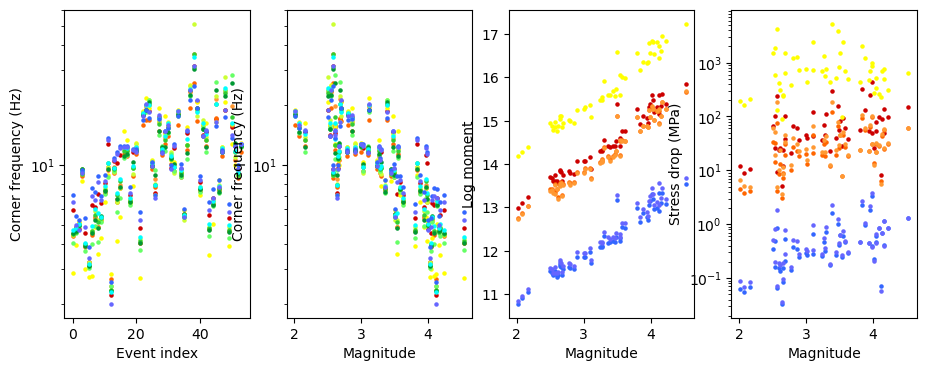

In [187]:


fig, axs = plt.subplots(1,4, figsize=(11,4))

for i, dname in enumerate(dnames):
    axs[0].scatter(D.index, D[f"fc_{dname}"], c=c[i], s=5)

    axs[1].scatter(D['mag'], D[f"fc_{dname}"], c=c[i], s=5)
    try:
        axs[2].scatter(D['mag'], D[f"logMo_{dname}"], c=c[i], s=5)
        axs[3].scatter(D['mag'], D[f"ds_{dname}"], c=c[i], s=5)
    except:
        print('', end='')
    # axs[3].scatter(df_ev['mean_logbeta_s'])

axs[0].set_yscale('log')
axs[1].set_yscale('log')
axs[3].set_yscale('log')

axs[0].set_xlabel("Event index")
axs[1].set_xlabel("Magnitude")
axs[2].set_xlabel("Magnitude")
axs[3].set_xlabel("Magnitude")
axs[0].set_ylabel("Corner frequency (Hz)")
axs[1].set_ylabel("Corner frequency (Hz)")
axs[2].set_ylabel("Log moment")
axs[3].set_ylabel("Stress drop (MPa)")
plt.show()


Normalize each dataset's fc values to go from 0 to 1

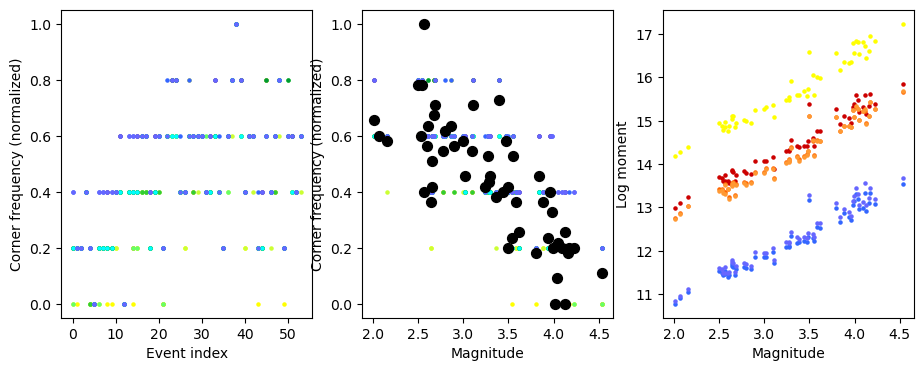

In [188]:


nbins = 5

for i, dname in enumerate(dnames):
    # method 2: binned fc
    fc = D[f'fc_{dname}'].values
    logfc = np.log10(fc)
    bins = np.linspace(min(logfc), max(logfc), nbins + 1)
    inds = np.digitize(logfc, bins=bins) - 1
    D[f'fcn_{dname}'] = inds/(nbins)

    # maybe equal number bins if this doesn't work?

    
    # # method 1: doesn't work well. too much scatter
    # ind = np.argsort(fc)
    # D[f'fcn_{dname}'] = ind/max(ind)

D['fcn_mean'] = 0
for i, dname in enumerate(dnames):
    D['fcn_mean'] += D[f'fcn_{dname}']
D['fcn_mean'] /= len(dnames)
# plt.figure()
# plt.scatter(D['mag'], np.log10(D['fc_PS1']), c='k')
# plt.scatter(D['mag'], D['fcn_PS1'], c='r')

fig, axs = plt.subplots(1,3, figsize=(11,4))

for i, dname in enumerate(dnames):
    axs[0].scatter(D.index, D[f"fcn_{dname}"], c=c[i], s=5)

    axs[1].scatter(D['mag'], D[f"fcn_{dname}"], c=c[i], s=5)
    try:
        axs[2].scatter(D['mag'], D[f"logMo_{dname}"], c=c[i], s=5)
    except:
        print('', end='')

axs[1].scatter(D['mag'], D["fcn_mean"], c='k', s=50)

# axs[0].set_yscale('log')
# axs[1].set_yscale('log')
# axs[2].set_yscale('log')

axs[0].set_xlabel("Event index")
axs[1].set_xlabel("Magnitude")
axs[2].set_xlabel("Magnitude")
axs[0].set_ylabel("Corner frequency (normalized)")
axs[1].set_ylabel("Corner frequency (normalized)")
axs[2].set_ylabel("Log moment")
plt.show()



Load data, index events and stations, and filter out bad results. This is to setup for the inverse problem.

In [189]:
data_dir = 'data/'
data_dir_files = os.listdir(data_dir)

# These are columns that are station-dependent, event-dependent, and 
# both-dependent. pandas pivot_table might be useful here
st_dep = ['stname', 'slat', 'slon', 'selev']
ev_dep = ['event_id', 'qmag', "qlon", "qlat", "qdep"]
dependents = ['beta', 'stn', 'deldist']

if all([el in data_dir_files for el in ['df.pkl', 'df_sta.pkl', 'df_ev.pkl']])\
    and load_df:
    print("Loading pre-computed DataFrames. Change 'load_df' to False to"
        " re-compute.")
    df = pd.read_pickle(data_dir + 'df.pkl')
    df_sta = pd.read_pickle(data_dir + 'df_sta.pkl')
    df_ev = pd.read_pickle(data_dir + 'df_ev.pkl')

    st_dep += ['sx', 'sy', 'stind']
    ev_dep += ['qx', 'qy', 'evind']
    dependents += ['distind', 'logbeta', 'logbeta_s']
else:

    print("Computing DataFrames from saved .beta files...")
    # read betatxt files into df_sta DataFrame
    # df_sta = read_betatxt_files(beta_dir)
    df_sta = read_beta_files(beta_dir)
    nstations_initial = len(df_sta)

    # remove undesired components
    inds = []
    for i, el in enumerate(df_sta['stname'].values):
        if el[-1].lower() in components: inds += [i]
    df_sta = df_sta.iloc[inds]
    df_sta.reset_index(drop=True, inplace=True)
    n_remove_components = nstations_initial-len(df_sta)
    print(f"{n_remove_components} channels removed based on components.")

    # remove undesired units
    inds = []
    for i, el in enumerate(df_sta['stname'].values):
        if el[-2].lower() in units: inds += [i]
    df_sta = df_sta.iloc[inds]
    df_sta.reset_index(drop=True, inplace=True)
    print(f"{nstations_initial-len(df_sta)+n_remove_components} channels "
    "removed based on seismogram units.")

    # Compute sx and sy (station easting and northing)
    df_sta['sx'], df_sta['sy'], zn, zl = utm.from_latlon(
        df_sta['slat'].values, 
        df_sta['slon'].values
        )
    st_dep += ['sx', 'sy']
    df_sta.reset_index(drop=True, inplace=True)

    # explode!
    df = df_sta.explode(ev_dep + dependents)
    df['event_id'] = df['event_id'].astype(int)
    df['qmag'] = df['qmag'].astype(float)
    df['qlat'] = df['qlat'].astype(float)
    df['qlon'] = df['qlon'].astype(float)
    df['qdep'] = df['qdep'].astype(float)
    df['beta'] = df['beta'].astype(float)
    df['stn'] = df['stn'].astype(float)
    df['deldist'] = df['deldist'].astype(float)
    df['logbeta'] = np.log10(df['beta'].values)
    nrecords_initial = len(df)
    dependents += ['logbeta']

    # get number of initial events
    nevents_initial = len(df['event_id'].unique())
    print(f"{nevents_initial} events, recorded by {nstations_initial} "
        f"stations, resulting in {nrecords_initial} records loaded.")

    # bin values by distance, first removing distant records
    df = df[df['deldist']<=dist_max]
    n_dmax_removed = nrecords_initial-len(df)
    print(f"{n_dmax_removed} distant (>{dist_max:.1f} km) records "
        "removed")

    df = df[df['deldist']>=dist_min]
    n_dmmin_removed = nrecords_initial-len(df)+n_dmax_removed
    print(f"{n_dmmin_removed} nearby (<{dist_min:.1f} km) records "
        "removed")
    df['distind'] = np.searchsorted(dist_bins, 
                                    df['deldist'].values.astype(float)) - 1
    dependents += ['distind']

    # filter out bad STN records
    df = df[df['stn']>=stn_req]
    df.reset_index(drop=True, inplace=True)
    print(f"{len(df)} records ({len(df)/nrecords_initial*100:.1f}%) passed "
        f"STN ratio requirement of {stn_req:.1f}")

    # make sure each earthquake has enough remaining records
    df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)
    # df_ev = df_ev[df_ev['stname'].map(len) >= nrecords_min].reset_index(drop=True)
    # df_ev = df_ev[df_ev['event_id'].isin(D['ID'])].reset_index(drop=True)
    print(f"{int(nevents_initial-len(df_ev))} events removed due to not enough"
        f" records (needs >= {nrecords_min})")

    # Compute qxs and qys of events
    df_ev['qx'], df_ev['qy'], zn, zl = utm.from_latlon(
        df_ev['qlat'].values, 
        df_ev['qlon'].values
        )
    ev_dep += ['qx', 'qy']
    df_ev.reset_index(drop=True, inplace=True)

    # add an event index value 'evind' and explode back into df
    df_ev['evind'] = df_ev.index.values.astype(int)
    ev_dep += ['evind']
    df = df_ev.explode(st_dep + dependents)
    df.reset_index(drop=True, inplace=True)

    # group by station to add index
    df_sta = df.groupby(st_dep, as_index=False)[ev_dep+dependents].agg(list)

    df_sta['logbeta_s'] = np.zeros(len(df_sta), dtype=object)
    drop_inds = []
    for i in range(len(df_sta)):
        row = df_sta.iloc[i]
        logbeta = np.log10(row['beta'])
        mag = np.array(row['qmag'])
        inds = np.where(np.logical_and(mag>=beta_shift_range[0], mag<beta_shift_range[1]))[0]
        corr = np.median(logbeta[inds])

        if np.isnan(corr): #np.logical_or(np.isnan(corr), len(inds)<ncorr_min): 
            drop_inds += [i]
        df_sta.at[i, 'logbeta_s'] = df_sta.at[i, 'logbeta'] - corr

    df_sta = df_sta.drop(index=drop_inds)
    df_sta.reset_index(drop=True, inplace=True)
    print(f"{len(drop_inds)} stations dropped due to not enough events in the correction range")

    df_sta['stind'] = df_sta.index.values.astype(int)
    st_dep += ['stind']
    dependents += ['logbeta_s']
    # print(drop_inds)
    # explode!
    df = df_sta.explode(ev_dep + dependents)
    df.reset_index(drop=True, inplace=True)

    # group by event
    df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)
    df_ev = df_ev[df_ev['event_id'].isin(D['ID'])].reset_index(drop=True)

    # Save DataFrames
    df.to_pickle(data_dir + "df.pkl")
    print(f"Saved df to {data_dir + 'df.pkl'}")
    df_sta.to_pickle(data_dir + "df_sta.pkl")
    print(f"Saved df_sta to {data_dir + 'df_sta.pkl'}")
    df_ev.to_pickle(data_dir + "df_ev.pkl")
    print(f"Saved df_ev to {data_dir + 'df_ev.pkl'}")



nevents = len(df_ev)
nstations = len(df_sta)
ndata = len(df)

# truncate dist_bins at maximum distance
dist_bins = dist_bins[:np.max(df['distind'])+2]

print("-------------")
print("Final counts:")
print("-------------")
print(f"{nevents} events")
print(f"{nstations} stations")
print(f"{ndata} records")


df_ev = pd.merge(df_ev, D, left_on='event_id', right_on='ID', suffixes=['',''])
df_ev.columns

Computing DataFrames from saved .beta files...
343 channels removed based on components.
686 channels removed based on seismogram units.
12942 events, recorded by 529 stations, resulting in 1101991 records loaded.
0 distant (>120.0 km) records removed
185494 nearby (<20.0 km) records removed
272463 records (24.7%) passed STN ratio requirement of 3.0
305 events removed due to not enough records (needs >= 1)


/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


31 stations dropped due to not enough events in the correction range
Saved df to data/df.pkl
Saved df_sta to data/df_sta.pkl
Saved df_ev to data/df_ev.pkl
-------------
Final counts:
-------------
54 events
129 stations
270668 records


Index(['event_id', 'qmag', 'qlon', 'qlat', 'qdep', 'qx', 'qy', 'evind',
       'stname', 'slat', 'slon', 'selev', 'sx', 'sy', 'stind', 'beta', 'stn',
       'deldist', 'logbeta', 'distind', 'logbeta_s', 'ID', 'logMo_AB', 'fc_AB',
       'ds_AB', 'logMo_DB1', 'fc_DB1', 'ds_DB1', 'logMo_DB2', 'fc_DB2',
       'ds_DB2', 'logMo_PD', 'fc_PD', 'ds_PD', 'fc_CP', 'fc_PS1', 'fc_PS2',
       'fc_PS3', 'fc_DT', 'fc_XC1', 'logMo_XC1', 'mag', 'ds_XC1', 'fc_XC2',
       'logMo_XC2', 'ds_XC2', 'fcn_AB', 'fcn_DB1', 'fcn_DB2', 'fcn_PD',
       'fcn_CP', 'fcn_PS1', 'fcn_PS2', 'fcn_PS3', 'fcn_DT', 'fcn_XC1',
       'fcn_XC2', 'fcn_mean'],
      dtype='object')

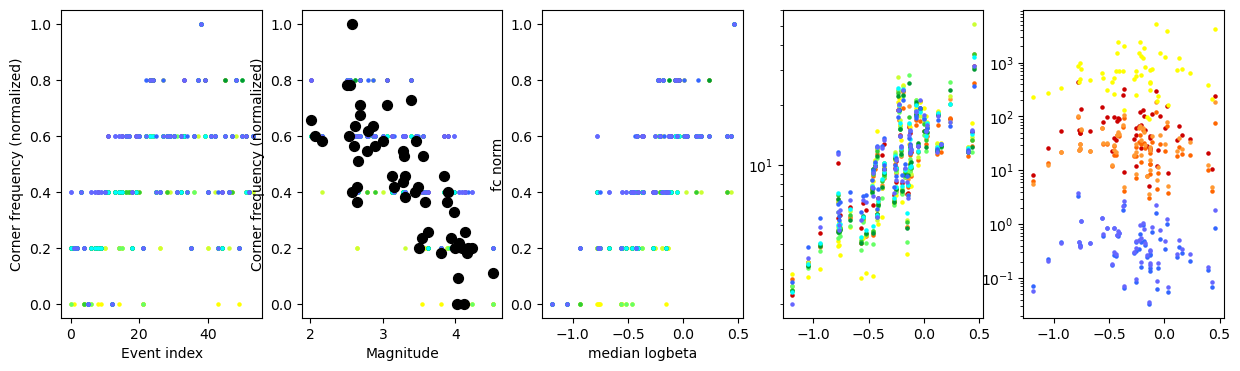

In [177]:
df_ev['mean_logbeta_s'] = df_ev['logbeta_s'].apply(np.median)


fig, axs = plt.subplots(1,5, figsize=(15,4))

for i, dname in enumerate(dnames):
    axs[0].scatter(df_ev.index, df_ev[f"fcn_{dname}"], c=c[i], s=5)

    axs[1].scatter(df_ev['qmag'], df_ev[f"fcn_{dname}"], c=c[i], s=5)
    try:
        axs[2].scatter(df_ev['mean_logbeta_s'], df_ev[f"fcn_{dname}"], c=c[i], s=5)
        axs[4].scatter(df_ev['mean_logbeta_s'], df_ev[f"ds_{dname}"], c=c[i], s=5)
    except:
        print('', end='')
    axs[3].scatter(df_ev['mean_logbeta_s'], df_ev[f'fc_{dname}'], c=c[i], s=5)

axs[1].scatter(df_ev['qmag'], df_ev["fcn_mean"], c='k', s=50)

# axs[0].set_yscale('log')
# axs[1].set_yscale('log')
# axs[2].set_yscale('log')
axs[3].set_yscale('log')
axs[4].set_yscale('log')

axs[0].set_xlabel("Event index")
axs[1].set_xlabel("Magnitude")
axs[2].set_xlabel("median logbeta")
axs[0].set_ylabel("Corner frequency (normalized)")
axs[1].set_ylabel("Corner frequency (normalized)")
axs[2].set_ylabel("fc norm")
plt.show()



## Visualize station corrections
Output figures for each station showing the range of correction events and their betas, and the final, station-corrected betas for each station

In [12]:
print(f"Station-corrected logbeta range: ({np.min(df['logbeta_s']):.3f}, {np.max(df['logbeta_s']):.3f})")

# # plotting values
# xlim = [-2.5, 2.5]
# nrows, ncols = 8, 4
# nstations_per_page = int(nrows*ncols)
# ax_b_scale = 0.333

# # histogram bin edges
# edges = np.linspace(xlim[0], xlim[1], 101)

# # kwargs common for every histogram
# hist_kwargs = {'linewidth': 0.5,
#                'histtype': 'step'}

# npages = 0
# for ns in range(nstations):
#     if ns % nstations_per_page == 0:
#         fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8.5,11), 
#             layout='tight', sharex=True)
#         axs = axs.flatten()
#         nplt = 0
#         npages += 1
    
#     # Store some values for station number ns
#     logbeta   = np.array(df_sta.at[ns, 'logbeta'])
#     logbeta_s = np.array(df_sta.at[ns, 'logbeta_s'])
#     mag       = np.array(df_sta.at[ns, 'qmag'])

#     # find the indices of the correction events
#     p = np.where(np.logical_and(mag>=beta_shift_range[0], mag<beta_shift_range[1]))[0]
#     corr = np.median(logbeta[p])

#     ax = axs[nplt]
#     ax.set_xlim(xlim)
#     ax_b = ax.twinx()

#     # Corrected beta
#     ax.hist(logbeta_s, bins=edges, color='k', **hist_kwargs)

#     # Uncorrected beta of the correction records
#     hst = ax_b.hist(logbeta[p], bins=edges, color='r', linestyle=':', **hist_kwargs)

#     # Corrected beta of the correction records
#     ax_b.hist(logbeta_s[p], bins=edges, color='r', **hist_kwargs)

#     # Plotting format
#     ax_b.set_ylim([0, max(hst[0]) / ax_b_scale])
#     ax_b.yaxis.label.set_color('red')
#     ax_b.spines['right'].set_color('red')
#     ax_b.tick_params(axis='y', colors='red')
#     ax.set_title(df_sta.at[ns, 'stname'])

#     # Text information
#     ax_b.text(0, 0.98, f"{len(logbeta_s)}", va='top', transform=ax_b.transAxes)
#     ax_b.text(0, 0.80, f"{len(p)}", color='r', va='top', transform=ax_b.transAxes)
#     ax_b.text(0.98, 0.98, f"Corr.:\n{corr:5.2f}", color='r', va='top', ha='right', 
#         transform=ax_b.transAxes)

#     # Title and save figures
#     if np.logical_or((ns+1) % nstations_per_page == 0, ns>=nstations-1): 
#         stmax = min([npages*nstations_per_page, nstations])
#         fig.suptitle(f"Stations {(npages-1)*nstations_per_page+1}-{stmax} of {nstations}\n"
#             f"Correction magnitudes M{beta_shift_range[0]}-M{beta_shift_range[1]}")
        
#         plt.savefig(f"figs/station_corrections_p{npages}.pdf", bbox_inches='tight')
#         plt.show()

#     nplt += 1
    


Station-corrected logbeta range: (-1.731, 0.146)


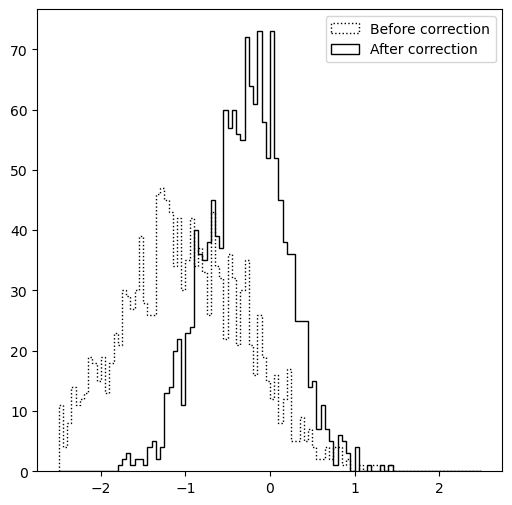

In [178]:
logbeta     = np.log10(df['beta'].values.astype(float))
logbeta_s   = df['logbeta_s'].values.astype(float)
mag         = df['qmag'].values.astype(float)

xlim = [-2.5, 2.5]

hist_kwargs = {'linewidth': 1,
               'histtype': 'step'}

edges = np.linspace(xlim[0], xlim[1], 101)

bins = [np.linspace(-4, 2, 101), np.arange(1, 7.2, 0.1)]

magrange = [0, 10]

p = np.where(np.logical_and(mag>=magrange[0], mag<magrange[1]))

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,6))
ax.hist(logbeta[p], bins=edges, color='k', linestyle=':', 
    label='Before correction', **hist_kwargs)
ax.hist(logbeta_s[p], bins=edges, color='k', label="After correction", 
    **hist_kwargs)
# plt.hist2d(logbeta, mag, bins=bins)

plt.legend()
plt.show()

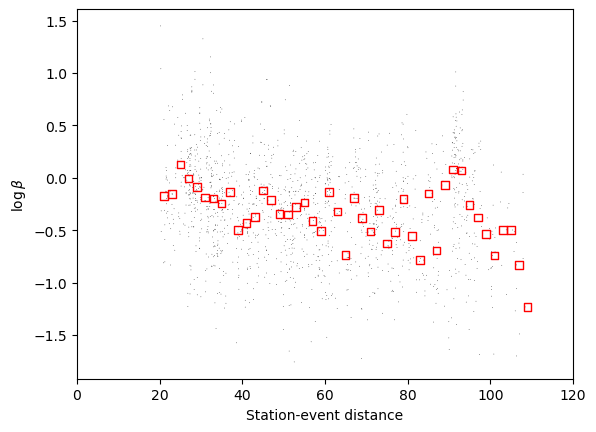

In [179]:

dist = df['deldist'].values.astype(float)
logbeta_s = df['logbeta_s'].values.astype(float)
edges = np.arange(0, 121, 2)

X, Y = get_bins_and_averages(dist, logbeta_s, edges, method='median')

plt.figure()
plt.scatter(dist, logbeta_s, c='k', s=1, marker='.', edgecolors='none')
plt.scatter(X, Y, marker='s', s=30, edgecolors='r', facecolors='none')
plt.xlim((0, 120))

plt.xlabel("Station-event distance")
plt.ylabel("$\\log \\beta$")
plt.show()



In [180]:
def boxplot(x, y, xbins, ax=None, color='r', **kwargs):

    if ax is None: ax = plt.gca()
    boxprops = dict(color=color)
    medianprops = dict(color=color, linewidth=2)
    whiskerprops = dict(color=color)
    capprops = dict(color=color)
    
    inds = np.digitize(x, bins=xbins) - 1

    xmids = (xbins[1:] + xbins[:-1]) / 2

    xmids = xmids[np.unique(inds)]

    xwidth = xbins[1]-xbins[0]
    
    # get data in proper format for boxplot. This forms a sequence of 1D
    # arrays
    X = [y[inds==i] for i in np.unique(inds)]

    keys = kwargs.keys()
    if 'positions' not in keys: kwargs = {**kwargs, 'positions': xmids}
    if 'manage_ticks' not in keys: kwargs = {**kwargs, 'manage_ticks': False}
    if 'widths' not in keys: kwargs = {**kwargs, 'widths': xwidth*0.8}
    if 'sym' not in keys: kwargs = {**kwargs, 'sym': ''}
    if 'whis' not in keys: kwargs = {**kwargs, 'whis': (5, 95)}

    if 'boxprops' not in keys: kwargs = {**kwargs, 'boxprops': boxprops}
    if 'medianprops' not in keys: kwargs = {**kwargs, 'medianprops': medianprops}
    if 'whiskerprops' not in keys: kwargs = {**kwargs, 'whiskerprops': whiskerprops}
    if 'capprops' not in keys: kwargs = {**kwargs, 'capprops': capprops}

    out = ax.boxplot(X, **kwargs)

    return out

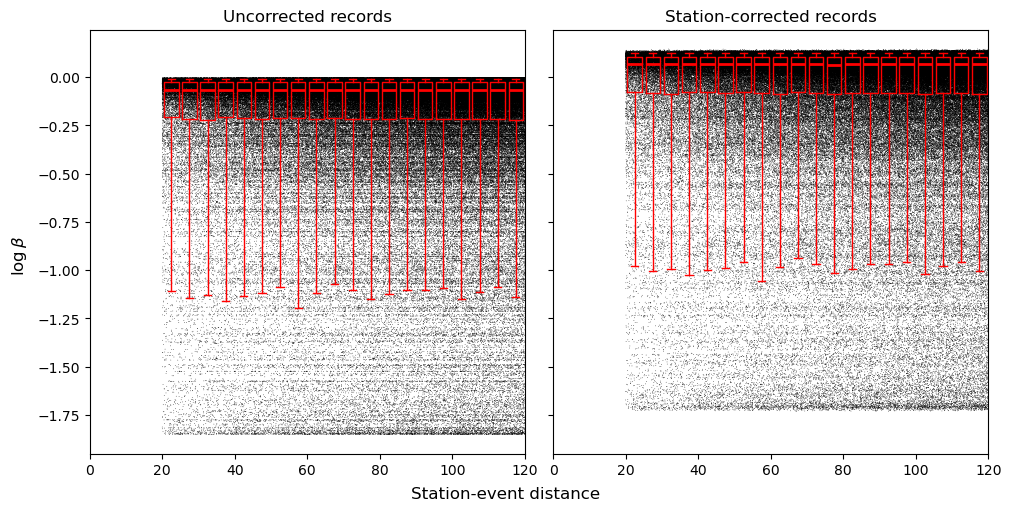

In [16]:

dist = df['deldist'].values.astype(float)
logbeta = df['logbeta'].values.astype(float)
logbeta_s = df['logbeta_s'].values.astype(float)
edges = np.arange(0, 121, 5)

boxplot_kwargs = {

}

hst1 = np.histogram(dist, bins=edges)

X1, Y1 = get_bins_and_averages(dist, logbeta, edges, method='median')
X2, Y2 = get_bins_and_averages(dist, logbeta_s, edges, method='median')

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,5), 
    sharex=True, sharey=True, layout='constrained')
boxplot(dist, logbeta, edges, ax=ax1)
ax1.scatter(dist, logbeta, c='k', s=1, marker='.', edgecolors='none')
# ax1.scatter(X1, Y1, marker='s', s=30, edgecolors='r', facecolors='none')


ax1.set_title('Uncorrected records')
ax1.set_xlim([0, 120])

ax2.scatter(dist, logbeta_s, c='k', s=1, marker='.', edgecolors='none')
boxplot(dist, logbeta_s, edges, ax=ax2)

# ax2.scatter(X2, Y2, marker='s', s=30, edgecolors='r', facecolors='none')
ax2.set_title("Station-corrected records")

fig.supxlabel("Station-event distance")
fig.supylabel("$\\log \\beta$")
plt.show()

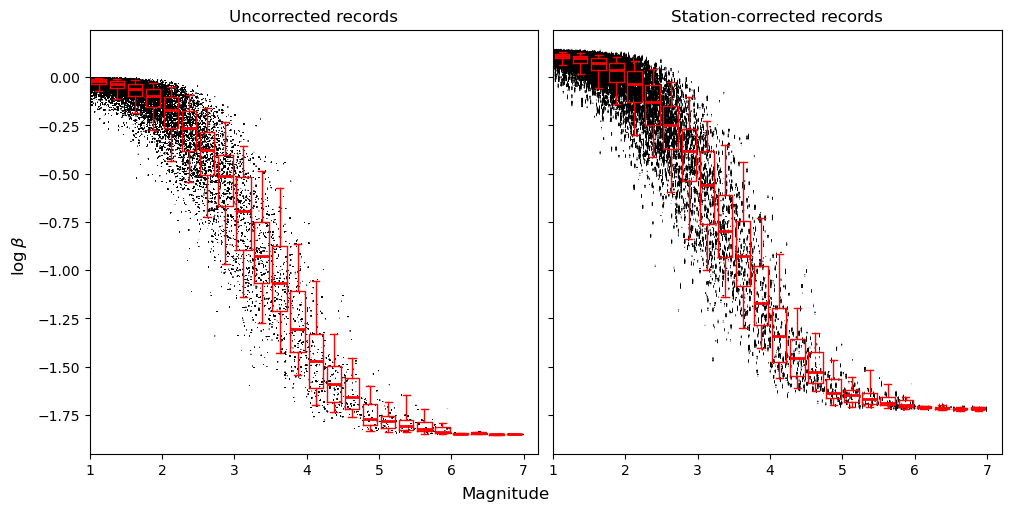

In [17]:

mag = df['qmag'].values.astype(float)
logbeta = df['logbeta'].values.astype(float)
logbeta_s = df['logbeta_s'].values.astype(float)
edges = np.arange(1, 7.27, 0.25)

X1, Y1 = get_bins_and_averages(mag, logbeta, edges, method='median')
X2, Y2 = get_bins_and_averages(mag, logbeta_s, edges, method='median')

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,5), 
    sharex=True, sharey=True, layout='constrained')
ax1.scatter(mag, logbeta, c='k', s=1, marker='.', edgecolors='none')
# ax1.scatter(X1, Y1, marker='s', s=30, edgecolors='r', facecolors='none')
boxplot(mag, logbeta, edges, ax=ax1)

ax1.set_title('Uncorrected records')
ax1.set_xlim([1, 7.2])

ax2.scatter(mag, logbeta_s, c='k', s=1, marker='.', edgecolors='none')
boxplot(mag, logbeta_s, edges, ax=ax2)
# ax2.scatter(X2, Y2, marker='s', s=30, edgecolors='r', facecolors='none')
ax2.set_title("Station-corrected records")

fig.supxlabel("Magnitude")
fig.supylabel("$\\log \\beta$")
plt.show()


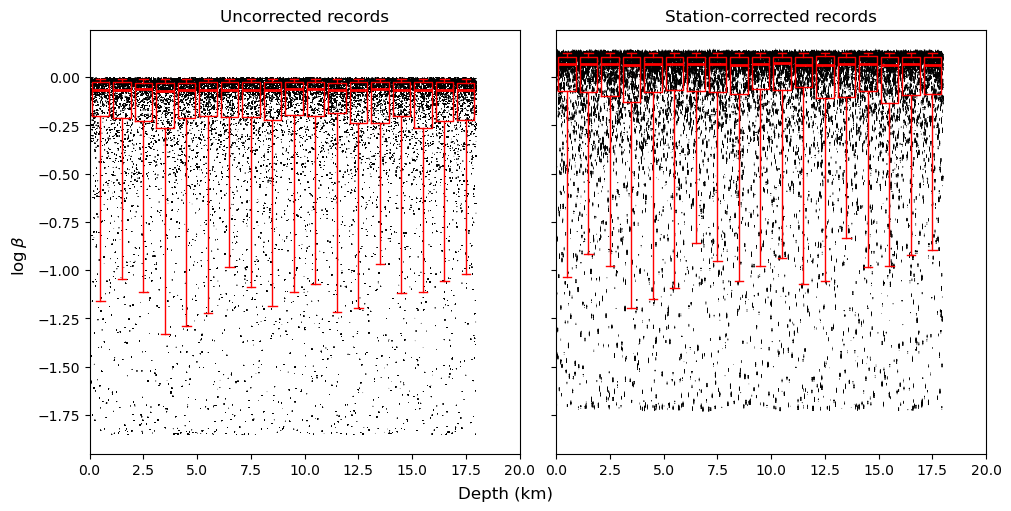

In [18]:

dep = df['qdep'].values.astype(float)
logbeta = df['logbeta'].values.astype(float)
logbeta_s = df['logbeta_s'].values.astype(float)
edges = np.arange(0, 25, 1)

X1, Y1 = get_bins_and_averages(dep, logbeta, edges, method='median')
X2, Y2 = get_bins_and_averages(dep, logbeta_s, edges, method='median')

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,5), 
    sharex=True, sharey=True, layout='constrained')
ax1.scatter(dep, logbeta, c='k', s=1, marker='.', edgecolors='none')
# ax1.scatter(X1, Y1, marker='s', s=30, edgecolors='r', facecolors='none')
boxplot(dep, logbeta, edges, ax=ax1)

ax1.set_title('Uncorrected records')
ax1.set_xlim([0, 20])

ax2.scatter(dep, logbeta_s, c='k', s=1, marker='.', edgecolors='none')
boxplot(dep, logbeta_s, edges, ax=ax2)
# ax2.scatter(X2, Y2, marker='s', s=30, edgecolors='r', facecolors='none')
ax2.set_title("Station-corrected records")

fig.supxlabel("Depth (km)")
fig.supylabel("$\\log \\beta$")
plt.show()


Take a look at some events

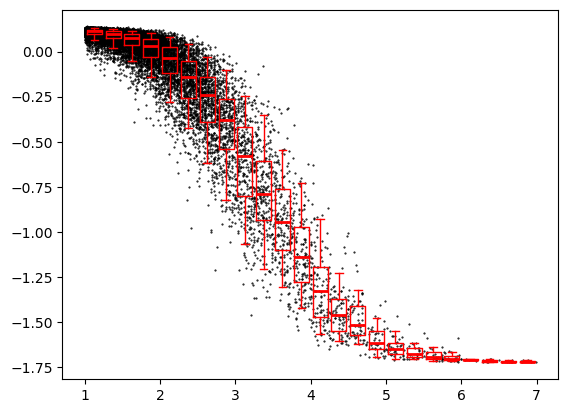

In [20]:
edges = np.arange(1, 8, 0.25)
df_ev['ev_logbeta'] = df_ev['logbeta_s'].apply(np.median)

mag = df_ev['qmag'].values.astype(float)
ev_logbeta = df_ev['ev_logbeta'].values.astype(float)

plt.figure()
plt.scatter(mag, ev_logbeta, c='k', s=1, marker='.')
boxplot(mag, ev_logbeta, edges, ax=plt.gca())
plt.show()


Make some checks

In [21]:
# number of events should equal number of unique evinds
assert len(df_ev['evind'])==len(df['evind'].unique())

# number of stations should equal number of unique stinds
assert len(df_sta['stind'])==len(df['stind'].unique())

# compute widths of each cross section
A_len = np.sqrt(np.sum(np.power(Ap - A, 2)))
B_len = np.sqrt(np.sum(np.power(Bp - B, 2)))
A_ratio = A_len / (A_len + B_len)
B_ratio = B_len / (A_len + B_len)
gridspec_kw = {"width_ratios": [A_ratio, B_ratio]}


# define 2 boxes by corners and their depths
B1 = (
    (4.5366E5, 3.94991E6),
    (4.5935E5, 3.94928E6),
    (4.6312E5, 3.94269E6),
    (4.5693E5, 3.93928E6)
    )
z1 = (0, 4)

B2 = (
    (4.4154E5, 3.96037E6),
    (4.4581E5, 3.96317E6),
    (4.5311E5, 3.95558E6),
    (4.4824E5, 3.95248E6)
    )
z2 = (0, 12)



# check which events are in the boxes
xyz = df_ev[['qx', 'qy', 'qdep']].values
pts = [Point(xyz[i,:2]) for i in range(len(xyz))]

B1poly = Polygon(B1)
B2poly = Polygon(B2)

B1_center = B1poly.centroid.coords.xy[0][0], B1poly.centroid.coords.xy[1][0]
B2_center = B2poly.centroid.coords.xy[0][0], B2poly.centroid.coords.xy[1][0]

in_dep1 = np.logical_and(xyz[:,2]>=z1[0], xyz[:,2]<=z1[1])
in_dep2 = np.logical_and(xyz[:,2]>=z2[0], xyz[:,2]<=z2[1])

df_ev['in_B1'] = np.logical_and(B1poly.contains(pts), in_dep1)
df_ev['in_B2'] = np.logical_and(B2poly.contains(pts), in_dep2)

print(f"{sum(df_ev['in_B1'])} events in box B1")
print(f"{sum(df_ev['in_B2'])} events in box B2")


0 events in box B1
0 events in box B2


Load Shearer et al. (2022) delsigs and compute averages inside boxes

In [22]:

delsig_df = pd.merge(delsig_cat, df_ev, how='inner', on='event_id')
# delsig_df = delsig_df[delsig_df['qmag'] <= 5.0]

print(f"{len(df_ev)} events in df_ev, {len(delsig_df)} events in delsig_df")

avg_B1_delsig = np.median(delsig_df['delsig'][delsig_df['in_B1']==True])
avg_B2_delsig = np.median(delsig_df['delsig'][delsig_df['in_B2']==True])

print(f"Average delsig in box B1 ({sum(delsig_df['in_B1'])} events): {avg_B1_delsig:.2f} MPa")
print(f"Average delsig in box B2 ({sum(delsig_df['in_B2'])} events): {avg_B2_delsig:.2f} MPa")



14551 events in df_ev, 14551 events in delsig_df
Average delsig in box B1 (0 events): nan MPa
Average delsig in box B2 (0 events): nan MPa


/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [23]:
delsig_df['logbeta_s'].values

array([list([np.float64(0.11373595542551611), np.float64(0.1178085578778912), np.float64(0.11627885747014159), np.float64(0.11889648962281822), np.float64(0.11731832174971969), np.float64(0.11576193051812579), np.float64(0.11495352023255039), np.float64(0.10840843066603519), np.float64(0.10574185510090688), np.float64(0.11688788642909116), np.float64(0.11600638034753684), np.float64(0.11523437862156659), np.float64(0.11537592965514067), np.float64(0.11523437862156659), np.float64(0.10661888660092954), np.float64(0.11061689078476335), np.float64(0.10727570399080989), np.float64(0.10552232510634592), np.float64(0.1132901885872614), np.float64(0.10374572977575276), np.float64(0.1061325352142495), np.float64(0.11600638034753684), np.float64(0.11732312715245082), np.float64(0.1174969153880407)]),
       list([np.float64(-0.04065210413955356), np.float64(-0.03741829512899267), np.float64(-0.03476992670445822), np.float64(-0.032126814532599135), np.float64(-0.03383607300265387), np.float64(-0

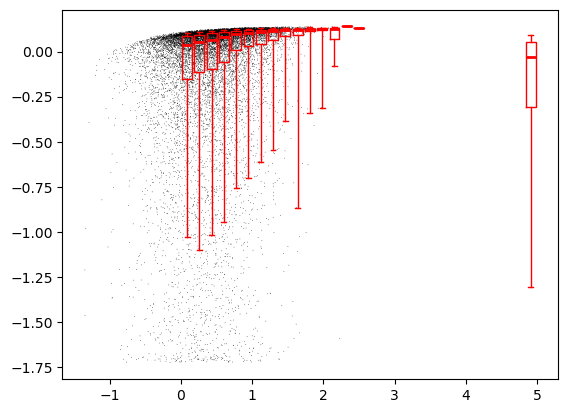

In [24]:
logdelsig = np.log10(delsig_df['delsig'].values)

edges = np.linspace(0, 5, 30)


plt.figure()
plt.scatter(logdelsig, delsig_df['ev_logbeta'].values, c='k', s=1, marker='.', edgecolors='none')
boxplot(logdelsig, delsig_df['ev_logbeta'].values, edges, ax=plt.gca())
# plt.xscale('log')
# plt.ylim([-0.25,0.25])
plt.show()


In [25]:
delsig_df.columns

Index(['event_id', 'delsig', 'm0', 'fc', 'qmag', 'qlon', 'qlat', 'qdep', 'qx',
       'qy', 'evind', 'stname', 'slat', 'slon', 'selev', 'sx', 'sy', 'stind',
       'beta', 'stn', 'deldist', 'logbeta', 'distind', 'logbeta_s',
       'ev_logbeta', 'in_B1', 'in_B2'],
      dtype='object')

In [157]:
logfc = np.log10(delsig_df['fc'].values)

edges = np.linspace(0, 5, 30)


plt.figure()
plt.scatter(delsig_df['ev_logbeta'].values, logfc, c='k', s=1, marker='.', edgecolors='none')
boxplot(logfc, delsig_df['ev_logbeta'].values, edges, ax=plt.gca())
# plt.xscale('log')
# plt.ylim([-0.25,0.25])
plt.show()

NameError: name 'delsig_df' is not defined

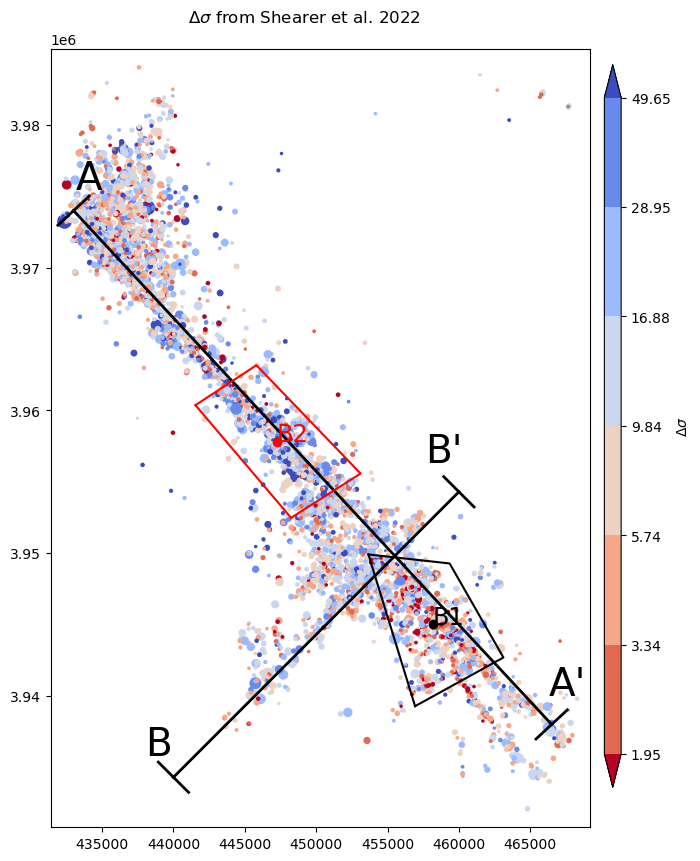

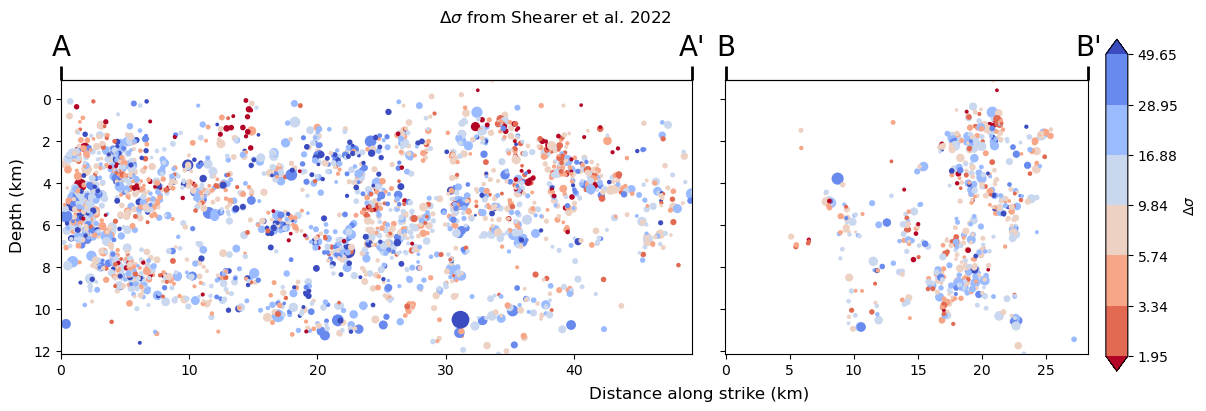

In [49]:

# plot the map-view and cross-sections of stress drop from Shearer et 
# al. (2022) for reference




df_plot = delsig_df
df_plot['easting'] = df_plot['qx']
df_plot['northing'] = df_plot['qy']
# df_plot = df_ev[np.logical_and(df_ev['qmag']>=1.6, df_ev['qmag']<1.8)]
# df_plot = df_ev[df_ev['qdep']<=1.0]
# df_plot = df_ev

dataname = 'delsig'
datatitle = r"$\Delta\sigma$"

cmap, smap, cnorm = get_colormap(df_plot[dataname].values, method='logmediancenter')

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 8.5),
    layout='constrained')
mapout = mt.plot_map(
    df_plot,
    ax=ax,
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

mt.plot_xsection_line(A, Ap, ax, labels=["A", "A'"], linewidth=2, 
    exact_tick_length=xsec_dmax)
mt.plot_xsection_line(B, Bp, ax, labels=["B", "B'"], linewidth=2, 
    exact_tick_length=xsec_dmax)

ax.scatter(*B1_center, c='k')
ax.scatter(*B2_center, c='r')

ax.text(*B1_center, "B1", fontsize='xx-large')
ax.text(*B2_center, "B2", fontsize='xx-large', color='r')

cb_ax = fig.add_axes([1.0,.080,.028,.85])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
smap.set_clim([cnorm.vmin, cnorm.vmax])

cbar.ax.set_ylabel(datatitle)
fig.suptitle(datatitle + " from Shearer et al. 2022")

plot_poly(B1, ax, color='k')
plot_poly(B2, ax, color='r')


fig, [ax1, ax2] = plt.subplots(nrows=1, ncols=2, figsize=(11, 4),
    sharey='all', sharex='col', gridspec_kw=gridspec_kw, layout='constrained')


importlib.reload(mt)
xsecoutA = mt.plot_xsection(
    df_plot, 
    p1 = A, 
    p2 = Ap, 
    max_dist = xsec_dmax,
    ax=ax1, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    )

xsecoutB = mt.plot_xsection(
    df_plot, 
    p1 = B, 
    p2 = Bp, 
    max_dist = xsec_dmax,
    ax=ax2, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    line_name="B"
    )


fig.supylabel("Depth (km)")
fig.supxlabel("Distance along strike (km)", x=0.63)
fig.suptitle(datatitle + " from Shearer et al. 2022")

# colorbar
cb_ax = fig.add_axes([1.0,.085,.02,.83])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
# smap.set_clim(clim)
# cbar.ax.set_yticks(cticks)
# cbar.ax.set_yticklabels(clabels)
cbar.ax.set_ylabel(datatitle)

# fig.canvas.draw_idle()

plt.show()




In [50]:
def smooth_by_nearest(C, values, n_neighbors, method=1):
    # C contains coordinates with same units 
    npts = len(C)
    

    if method==1:
        smoothed = np.zeros(len(values), dtype=float)
        for i in range(npts):
            point = C[i]
            dists = np.sqrt(np.sum(np.power(C - point, 2), axis=-1))
            inds = np.argpartition(dists, n_neighbors)[:n_neighbors]
            median_value = np.median(values[inds])
            
            smoothed[inds] = median_value
            # or should I make a copy of C first, then use that?
    elif method==2:
        smoothed = copy.deepcopy(values)
        for i in range(npts):
            point = C[i]
            dists = np.sqrt(np.sum(np.power(C - point, 2), axis=-1))
            inds = np.argpartition(dists, n_neighbors)[:n_neighbors]
            median_value = np.median(smoothed[inds])
            
            smoothed[inds] = median_value
            # or should I make a copy of C first, then use that?
    return smoothed


XYZ = df_ev[['qx', 'qy', 'qdep']].values.astype(float)
XYZ[:, 2] *= 1000


df_ev['logbeta_smooth'] = smooth_by_nearest(XYZ, df_ev['ev_logbeta'].values.astype(float), 4)

/Users/ivandevert/prog/mapping-tools/mapping_tools.py:84: RuntimeWarning: invalid value encountered in log10
  cticks = np.logspace(np.log10(clim[0]), np.log10(clim[1]), 5)


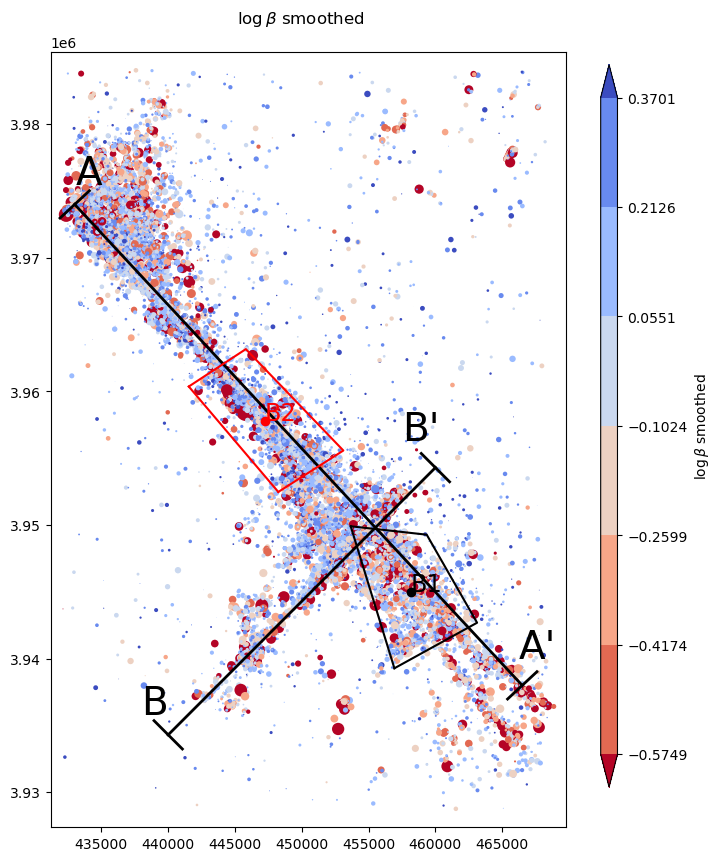

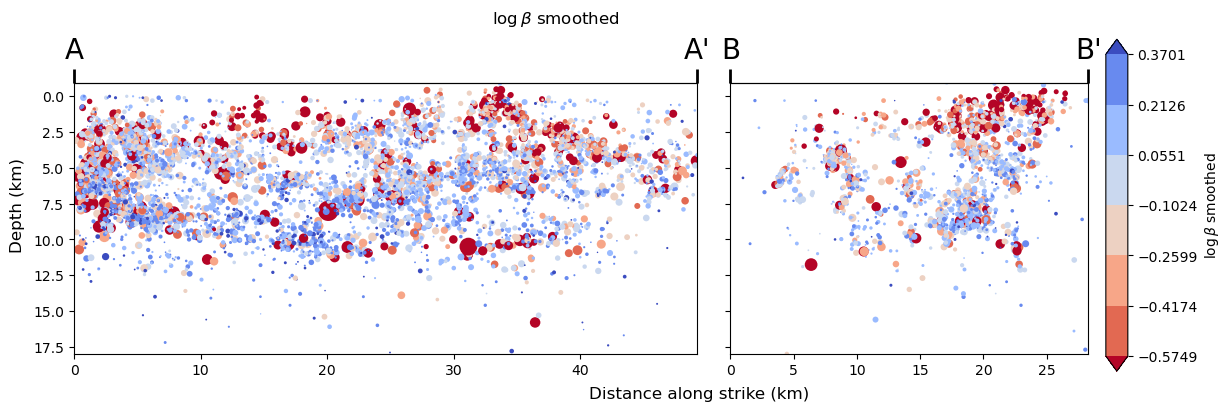

In [51]:




df_plot = df_ev
df_plot['easting'] = df_plot['qx']
df_plot['northing'] = df_plot['qy']
# df_plot = df_ev[np.logical_and(df_ev['qmag']>=1.6, df_ev['qmag']<1.8)]
# df_plot = df_ev[df_ev['qdep']<=1.0]
# df_plot = df_ev

# dataname = 'logbeta_smooth'
dataname = 'ev_logbeta'
datatitle = r"$\log\beta$ smoothed"

# cmap, smap, cnorm = get_colormap(df_plot[dataname].values, method='mediancenter')
cmap, smap, cnorm = get_colormap(df_plot[dataname].values, method='percentile', percentiles=[0.05, 0.95])

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 8.5),
    layout='constrained')
mapout = mt.plot_map(
    df_plot,
    ax=ax,
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

mt.plot_xsection_line(A, Ap, ax, labels=["A", "A'"], linewidth=2, 
    exact_tick_length=xsec_dmax)
mt.plot_xsection_line(B, Bp, ax, labels=["B", "B'"], linewidth=2, 
    exact_tick_length=xsec_dmax)

ax.scatter(*B1_center, c='k')
ax.scatter(*B2_center, c='r')

ax.text(*B1_center, "B1", fontsize='xx-large')
ax.text(*B2_center, "B2", fontsize='xx-large', color='r')

cb_ax = fig.add_axes([1.0,.080,.028,.85])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
smap.set_clim([cnorm.vmin, cnorm.vmax])

cbar.ax.set_ylabel(datatitle)
fig.suptitle(datatitle)

plot_poly(B1, ax, color='k')
plot_poly(B2, ax, color='r')


fig, [ax1, ax2] = plt.subplots(nrows=1, ncols=2, figsize=(11, 4),
    sharey='all', sharex='col', gridspec_kw=gridspec_kw, layout='constrained')


importlib.reload(mt)
xsecoutA = mt.plot_xsection(
    df_plot, 
    p1 = A, 
    p2 = Ap, 
    max_dist = xsec_dmax,
    ax=ax1, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    )

xsecoutB = mt.plot_xsection(
    df_plot, 
    p1 = B, 
    p2 = Bp, 
    max_dist = xsec_dmax,
    ax=ax2, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    line_name="B"
    )


fig.supylabel("Depth (km)")
fig.supxlabel("Distance along strike (km)", x=0.63)
fig.suptitle(datatitle)

# colorbar
cb_ax = fig.add_axes([1.0,.085,.02,.83])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
# smap.set_clim(clim)
# cbar.ax.set_yticks(cticks)
# cbar.ax.set_yticklabels(clabels)
cbar.ax.set_ylabel(datatitle)

# fig.canvas.draw_idle()

plt.show()


In [52]:
# separate DataFrames for events in each box
df_1 = df_ev[df_ev['in_B1']==True].reset_index(drop=True, inplace=False)
df_2 = df_ev[df_ev['in_B2']==True].reset_index(drop=True, inplace=False)

df_1.drop(labels=['in_B1', 'in_B2'], axis='columns')
df_2.drop(labels=['in_B1', 'in_B2'], axis='columns')

df_1 = df_1.explode(st_dep + dependents).reset_index(drop=True, inplace=False)
st_1 = df_1.groupby(st_dep, as_index=False)[ev_dep+dependents].agg(list)

df_2 = df_2.explode(st_dep + dependents).reset_index(drop=True, inplace=False)
st_2 = df_2.groupby(st_dep, as_index=False)[ev_dep+dependents].agg(list)

# df_box_1 = st_1.explode(ev_dep + dependents).reset_index(drop=True, inplace=False)
# df_box_2 = st_2.explode(ev_dep + dependents).reset_index(drop=True, inplace=False)

# df_box_1.to_csv(data_dir + "box1.txt", )
# df_box_2.to_csv(data_dir + "box2.txt", )

# import pandas as pd
# df1 = pd.read_csv('box1.txt')
# df2 = pd.read_csv('box2.txt')

# st_dep = ['stname', 'slat', 'slon', 'selev', 'sx', 'sy', 'stind']
# ev_dep = ['event_id', 'qmag', 'qlon', 'qlat', 'qdep', 'qx', 'qy', 'evind']
# both_dep = ['beta', 'stn', 'deldist', 'distind']
# df1_sta = df1.groupby(st_dep, as_index=False)[ev_dep+both_dep].agg(list)
# df2_sta = df2.groupby(st_dep, as_index=False)[ev_dep+both_dep].agg(list)

Calculate box-station distances

In [53]:
edges = np.arange(2, 5.1, 0.2)
# edges = np.arange(1, 2.01, 0.2)




def compute_beta_shift(row, m_range):
    qmag = np.array(row['qmag'])
    logbeta = np.log10(row['beta'])
    inds = np.where(np.logical_and(qmag>=m_range[0], qmag<m_range[1]))[0]

    shifted_beta = np.power(10, logbeta - np.median(logbeta[inds]))

    return shifted_beta

st_1['shifted_beta'] = st_1.apply(compute_beta_shift, axis=1, m_range=beta_shift_range)
st_2['shifted_beta'] = st_2.apply(compute_beta_shift, axis=1, m_range=beta_shift_range)

st_1['shift'] = np.log10([el[0] for el in (st_1['beta'] / st_1['shifted_beta']).values])
st_2['shift'] = np.log10([el[0] for el in (st_2['beta'] / st_2['shifted_beta']).values])

# compute the slopes and average distances in each
st_1[['beta_slope', 'beta_y']] = st_1.apply(get_slope, axis=1, result_type='expand', edges=edges)
st_2[['beta_slope', 'beta_y']] = st_2.apply(get_slope, axis=1, result_type='expand', edges=edges)

st_1['avg_dist'] = st_1['deldist'].apply(np.median)
st_2['avg_dist'] = st_2['deldist'].apply(np.median)

s1_xy = st_1[["sx", "sy"]].values.astype(float)
s2_xy = st_2[["sx", "sy"]].values.astype(float)

st_1['B1_sdist'] = np.sqrt(np.sum(np.power(s1_xy - B1_center, 2), axis=1)) / 1000
st_1['B2_sdist'] = np.sqrt(np.sum(np.power(s1_xy - B2_center, 2), axis=1)) / 1000
st_1['B_deldist'] = st_1['B1_sdist'] - st_1['B2_sdist']

st_2['B1_sdist'] = np.sqrt(np.sum(np.power(s2_xy - B1_center, 2), axis=1)) / 1000
st_2['B2_sdist'] = np.sqrt(np.sum(np.power(s2_xy - B2_center, 2), axis=1)) / 1000
st_2['B_deldist'] = st_2['B1_sdist'] - st_2['B2_sdist']


ST = pd.merge(st_1, st_2, how='inner', on=st_dep+['B1_sdist', 'B2_sdist', 'B_deldist'])
print(f"Box B1 median slope: {np.nanmedian(st_1['beta_slope'].values)}")
print(f"Box B2 median slope: {np.nanmedian(st_2['beta_slope'].values)}")




/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Box B1 median slope: -0.4434929239305715
Box B2 median slope: -0.43750348510047293


Plot the shifted betas

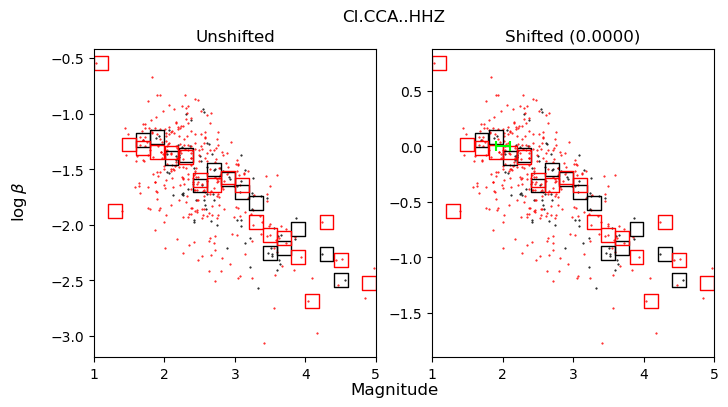

<Figure size 640x480 with 0 Axes>

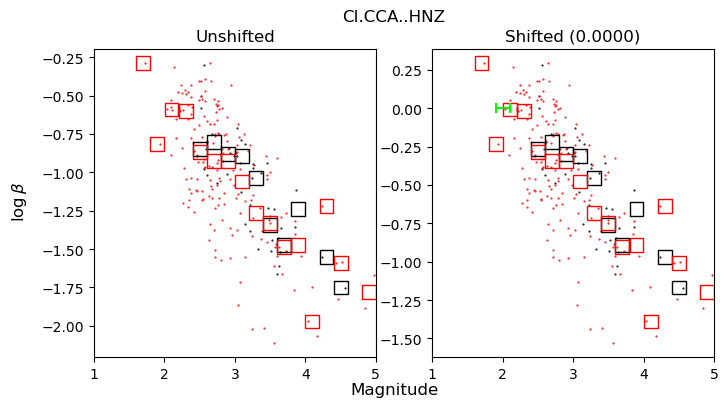

<Figure size 640x480 with 0 Axes>

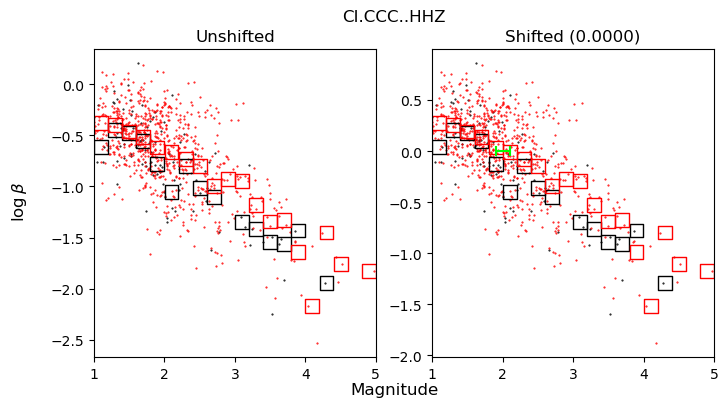

<Figure size 640x480 with 0 Axes>

Box B1 median slope: -0.4355791496855132
Box B2 median slope: -0.42751499258592573
Median difference: -0.011060584157723846


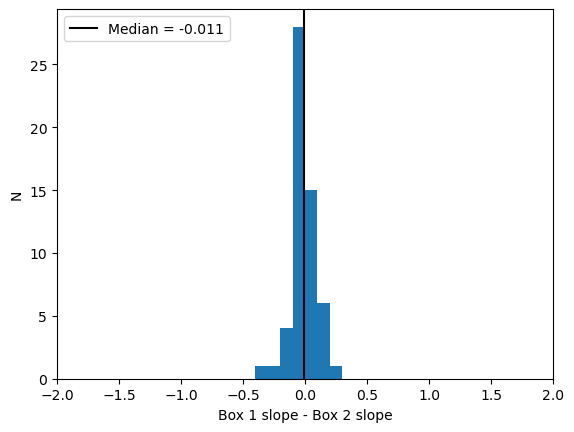

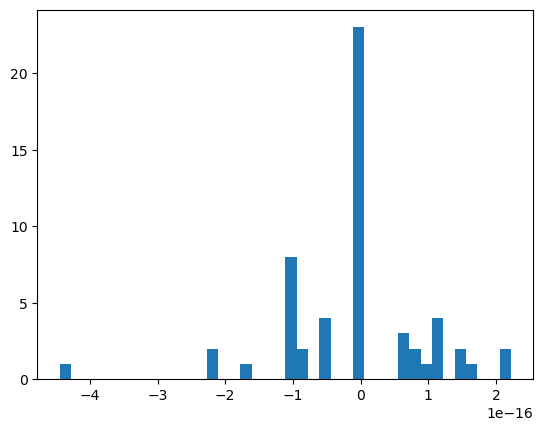

/var/folders/n9/y3b20y1x2dx7n3qq1qn2cn2m000jzz/T/ipykernel_62766/2184319363.py:147: RuntimeWarning: All-NaN slice encountered
  Y1_med = np.nanmedian(np.array(Y1), axis=0)
/var/folders/n9/y3b20y1x2dx7n3qq1qn2cn2m000jzz/T/ipykernel_62766/2184319363.py:148: RuntimeWarning: All-NaN slice encountered
  Y2_med = np.nanmedian(np.array(Y2), axis=0)


Median diff: 0.22335016437834931


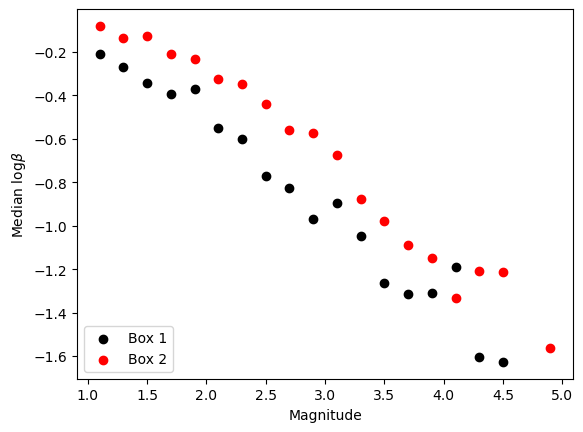

In [54]:
xlim = [1, 5]
X = np.array([0, 5])

edges_all = np.arange(1, 5.1, 0.2)
mids_all = (edges_all[1:] + edges_all[:-1]) / 2
slope1 = np.empty(len(st_1), dtype=float)
slope2 = np.empty(len(st_1), dtype=float)

B1_deldist = np.empty(len(st_1), dtype=float)
B2_deldist = np.empty(len(st_1), dtype=float)

relative_shift = np.empty(len(st_1), dtype=float)

B1_deldist[:] = np.nan
B2_deldist[:] = np.nan

relative_shift[:] = np.nan

Y1 = []
Y2 = []

# loop over common stations
slope1[:] = np.nan
slope2[:] = np.nan
for i in range(64):
    stid = st_1['stname'].values[i]
    j = np.where(st_2['stname'].values==stid)[0]

    # if station is common to both DFs, then:
    if len(j)>0:
        j = j[0]
        qmag1 = np.array(st_1.at[i, 'qmag'])
        beta1 = np.array(st_1.at[i, 'beta'])
        # shifted_beta1 = np.array(st_1.at[i, 'shifted_beta'])
        shifted_beta1 = np.power(10, st_1.at[i, 'logbeta_s'])

        qmag2 = np.array(st_2.at[j, 'qmag'])
        beta2 = np.array(st_2.at[j, 'beta'])
        # shifted_beta2 = np.array(st_2.at[j, 'shifted_beta'])
        shifted_beta2 = np.power(10, st_2.at[j, 'logbeta_s'])

        shift1 = np.log10(beta1[0]/shifted_beta1[0])
        shift2 = np.log10(beta2[0]/shifted_beta2[0])

        relative_shift[i] = shift1 - shift2

        if len(qmag1) >10:
            # print(sum(qmag1<=3.0), sum(qmag2<=3.0), st_1['stname'].values[i], st_2['stname'].values[j])
            assert st_1['stname'].values[i]==st_2['stname'].values[j], print('uh oh')

            Yavg1, _, bin_inds1 = scipy.stats.binned_statistic(qmag1, np.log10(beta1), bins=edges_all, statistic='median')
            Yavg2, _, bin_inds2 = scipy.stats.binned_statistic(qmag2, np.log10(beta2), bins=edges_all, statistic='median')
            # print(Yavg1)

            Y1.append(Yavg1)
            Y2.append(Yavg2)

            Xavg1 = mids_all[~np.isnan(Yavg1)]
            Xavg2 = mids_all[~np.isnan(Yavg2)]

            # compute bins that are in common
            inds1 = np.array([i for i in range(len(Xavg1)) if Xavg1[i] in Xavg2])
            inds2 = np.array([i for i in range(len(Xavg2)) if Xavg2[i] in Xavg1])

            sYavg1, _, sbin_inds1 = scipy.stats.binned_statistic(qmag1, np.log10(shifted_beta1), bins=edges_all, statistic='median')
            sYavg2, _, sbin_inds2 = scipy.stats.binned_statistic(qmag2, np.log10(shifted_beta2), bins=edges_all, statistic='median')

            sXavg1 = mids_all[~np.isnan(sYavg1)]
            sXavg2 = mids_all[~np.isnan(sYavg2)]

            if len(Xavg1)>1 and len(Xavg2)>1:
                # M1 = fit_line_p_norm(Xavg1, Yavg1, 1)
                # M2 = fit_line_p_norm(Xavg2, Yavg2, 1)

                M1 = st_1[['beta_slope', 'beta_y']].values[i,:]
                M2 = st_2[['beta_slope', 'beta_y']].values[j,:]

                slope1[i] = M1[0]
                slope2[i] = M2[0]

                B1_deldist[i] = st_1['B1_sdist'].values[i] - st_2['B1_sdist'].values[j]
                B2_deldist[i] = st_1['B2_sdist'].values[i] - st_2['B2_sdist'].values[j]


                if i < 5:
                    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8,4))
                    plt.figure()
                    fig.suptitle(st_1['stname'].values[i])
                    ax1.scatter(qmag1, np.log10(beta1), c='k', s=1, marker='.')
                    ax1.scatter(qmag2, np.log10(beta2), c='r', s=1, marker='.')
                    ax1.scatter(Xavg1, Yavg1[~np.isnan(Yavg1)], edgecolors='k', s=100, marker='s', facecolor='none')
                    ax1.scatter(Xavg2, Yavg2[~np.isnan(Yavg2)], edgecolors='r', s=100, marker='s', facecolor='none')

                    ax2.scatter(qmag1, np.log10(shifted_beta1), c='k', s=1, marker='.')
                    ax2.scatter(qmag2, np.log10(shifted_beta2), c='r', s=1, marker='.')
                    ax2.scatter(sXavg1, sYavg1[~np.isnan(sYavg1)], edgecolors='k', s=100, marker='s', facecolor='none')
                    ax2.scatter(sXavg2, sYavg2[~np.isnan(sYavg2)], edgecolors='r', s=100, marker='s', facecolor='none')

                    # ax2.scatter(sum(beta_shift_range)/2, 0, c='k', marker='x', s=80, zorder=100)
                    ax2.plot(beta_shift_range, [0,0], c='lime', zorder=100)
                    ax2.scatter(beta_shift_range, [0,0], c='lime', marker='|', s=50, zorder=100)
                    
                    ax1.set_xlim(xlim)
                    ax2.set_xlim(xlim)

                    ax1.set_title("Unshifted")
                    ax2.set_title(f"Shifted ({relative_shift[i]:.4f})")
                    # plt.yscale('log')

                    # plt.plot(X, M1[0]*X + M1[1], c='k', label='Box 1 fit')
                    # plt.plot(X, M2[0]*X + M2[1], c='r', label='Box 2 fit')

                    fig.supxlabel("Magnitude")
                    fig.supylabel(r"$\log \beta$")

                    plt.show()



keep_bool = ~np.logical_or(np.isnan(slope1), np.isnan(slope2))
slope1 = slope1[keep_bool]
slope2 = slope2[keep_bool]
B1_deldist = B1_deldist[keep_bool]
B2_deldist = B2_deldist[keep_bool]
relative_shift = relative_shift[keep_bool]
slopediff = slope1 - slope2

print(f"Box B1 median slope: {np.nanmedian(slope1)}")
print(f"Box B2 median slope: {np.nanmedian(slope2)}")
print(f"Median difference: {np.nanmedian(slopediff)}")

bins = np.linspace(-2, 2, 41)
plt.figure()
plt.hist(slopediff, bins=bins)
plt.axvline(np.nanmedian(slopediff), c='k', label=f'Median = {np.nanmedian(slopediff):.3f}')
plt.xlabel('Box 1 slope - Box 2 slope')
plt.ylabel('N')
plt.legend(loc='upper left')
plt.xlim((-2, 2))
plt.show()

plt.figure()
plt.hist(relative_shift, 40)
plt.show()


Y1_med = np.nanmedian(np.array(Y1), axis=0)
Y2_med = np.nanmedian(np.array(Y2), axis=0)

print(f"Median diff: {np.nanmedian(Y2_med-Y1_med)}")

plt.figure()
plt.scatter(mids_all, Y1_med, c='k', label='Box 1')
plt.scatter(mids_all, Y2_med, c='r', label='Box 2')
# plt.plot(mids_all, Y2_med-Y1_med)
# plt.plot(mids_all, np.array(Y1).T, c='k', linewidth=0.1)
# plt.plot(mids_all, np.array(Y2).T-np.array(Y1).T, c='r', linewidth=0.1)

plt.xlabel("Magnitude")
plt.ylabel("Median log$\\beta$")

plt.legend(loc='lower left')
plt.show()

# slope2 = np.zeros(len(st_2)) - 99.0
# for i in range(len(st_2)):
#     qmag = np.array(st_2.at[i, 'qmag'])
#     beta = np.array(st_2.at[i, 'beta'])

#     if len(qmag) >1:

#         M = fit_line_p_norm(qmag, np.log10(beta), 1)
#         slope2[i] = M[0]

In [55]:
# df_box_1 = st_1.explode(ev_dep + dependents).reset_index(drop=True, inplace=False)
# df_box_2 = st_2.explode(ev_dep + dependents).reset_index(drop=True, inplace=False)

# df_box_1.to_csv(data_dir + "box1.txt", )
# df_box_2.to_csv(data_dir + "box2.txt", )

In [56]:
ST['beta_slope_diff'] = ST['beta_slope_x'] - ST['beta_slope_y']
ST = ST.drop(index=np.where(np.isnan(ST['beta_slope_diff'].values))[0])
ST.reset_index(drop=True, inplace=True)

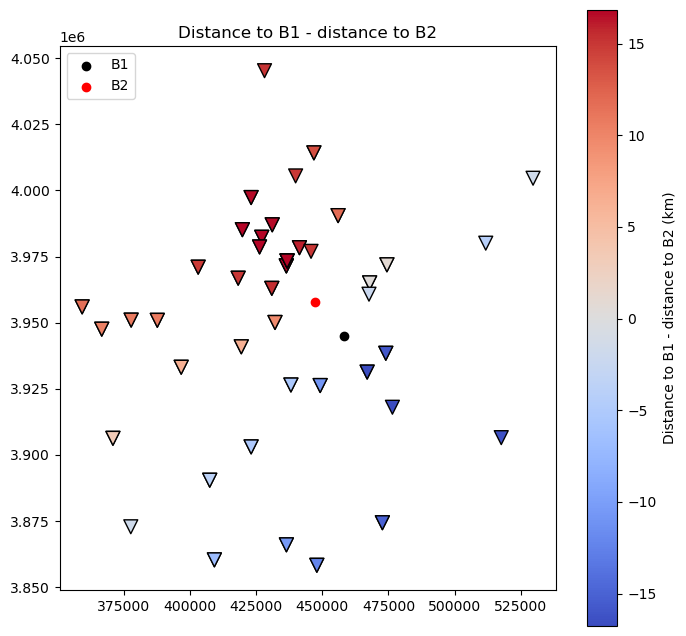

In [57]:

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,8))
sc = ax.scatter(ST['sx'], ST['sy'], edgecolors='k', c=ST['B_deldist'], s=100, marker='v', cmap='coolwarm', norm='linear')
ax.scatter(*B1_center, c='k', label='B1')
ax.scatter(*B2_center, c='r', label='B2')
ax.set_aspect('equal', adjustable='box')
ax.set_title("Distance to B1 - distance to B2")

cbar = plt.colorbar(sc)
cbar.ax.set_ylabel('Distance to B1 - distance to B2 (km)')
plt.legend(loc='upper left')
plt.show()


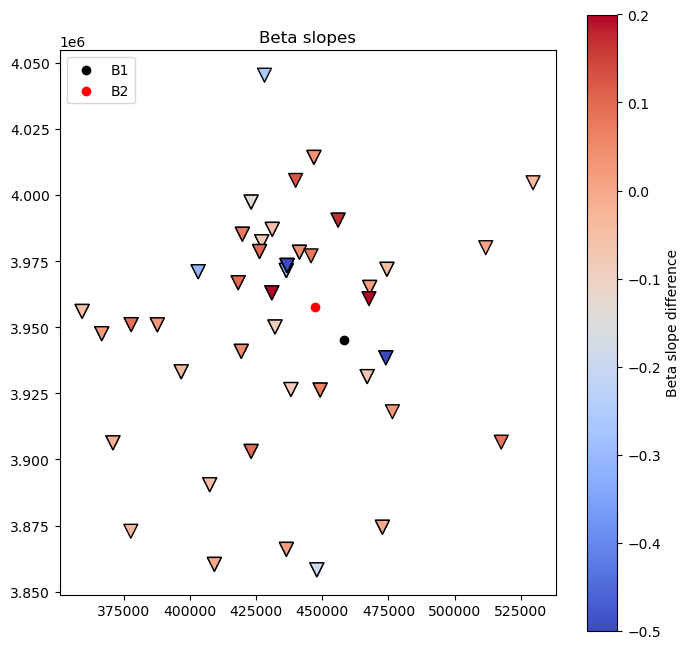

In [58]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,8))
sc = ax.scatter(ST['sx'], ST['sy'], edgecolors='k', c=ST['beta_slope_diff'], s=100, marker='v', cmap='coolwarm', norm='linear', vmin=-0.5, vmax=0.2)
ax.scatter(*B1_center, c='k', label='B1')
ax.scatter(*B2_center, c='r', label='B2')
ax.set_aspect('equal', adjustable='box')
ax.set_title("Beta slopes")

cbar = plt.colorbar(sc)
cbar.ax.set_ylabel('Beta slope difference')
plt.legend(loc='upper left')
plt.show()

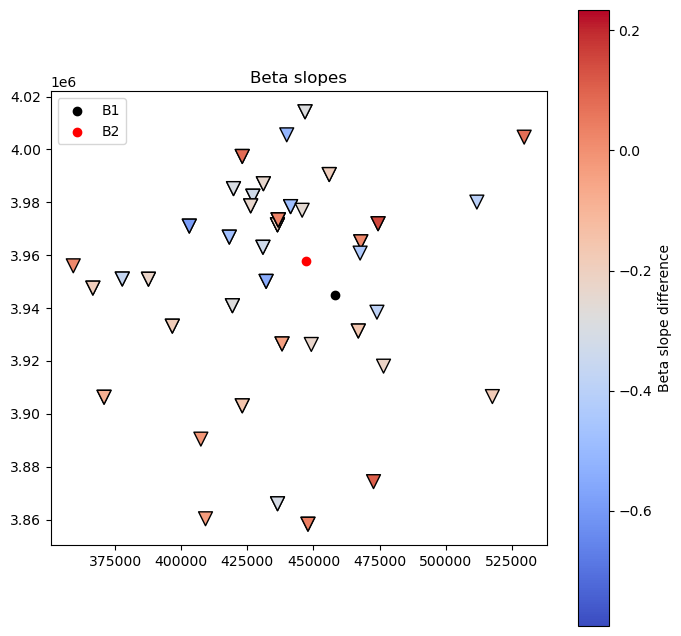

In [59]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,8))
sc = ax.scatter(ST['sx'], ST['sy'], edgecolors='k', c=ST['shift_x'] - ST['shift_y'], s=100, marker='v', cmap='coolwarm', norm='linear')
ax.scatter(*B1_center, c='k', label='B1')
ax.scatter(*B2_center, c='r', label='B2')
ax.set_aspect('equal', adjustable='box')
ax.set_title("Beta slopes")

cbar = plt.colorbar(sc)
cbar.ax.set_ylabel('Beta slope difference')
plt.legend(loc='upper left')
plt.show()

In [60]:
# def fit_line_emcee(x, y, nwalkers=16):

#     # first, fit the line with a 2 norm
#     M = fit_line_p_norm(qmag, np.log10(beta), 2)


#     # perturb solution
#     ndim = len(M)
#     pos = M + 1e-4 * np.random.randn(nwalkers, ndim)

#     sampler = emcee.EnsembleSampler(
#         nwalkers, ndim, log_probability, args=(x, y, yerr)
#     )

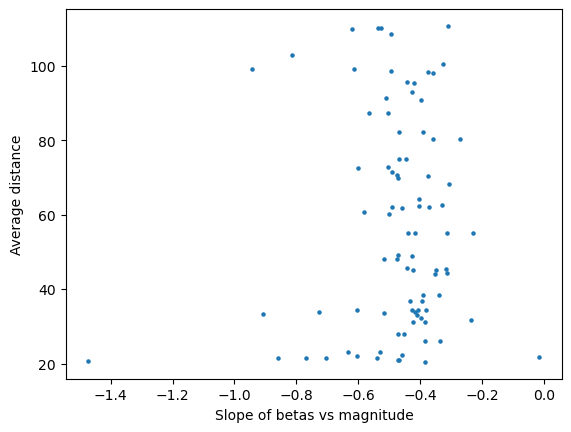

In [61]:
plt.figure()
plt.scatter(np.array(st_1['beta_slope']), np.array(st_1['avg_dist']), s=5)
plt.xlabel("Slope of betas vs magnitude")
plt.ylabel('Average distance')
plt.show()

-0.4434929239305715
-0.43750348510047293


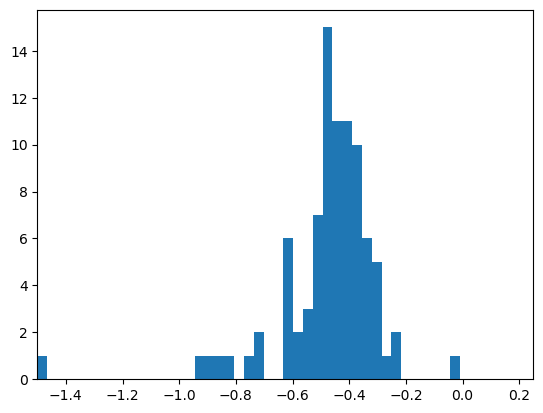

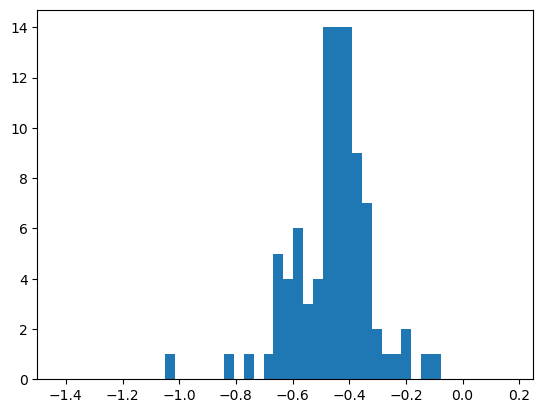

In [62]:
bins = np.linspace(-1.5, 0.2, 50)

print(np.nanmedian(st_1['beta_slope']))
print(np.nanmedian(st_2['beta_slope']))

plt.hist(st_1['beta_slope'], bins=bins)
plt.xlim((-1.5, 0.25))
plt.show()
plt.hist(st_2['beta_slope'], bins=bins)
plt.xlim((-1.5, 0.25))
plt.show()

49.06819534301758
32.49379634857178


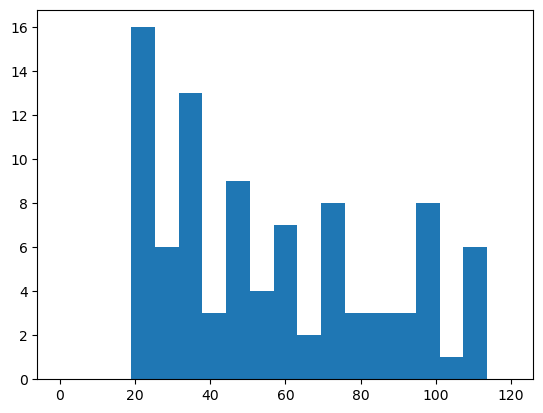

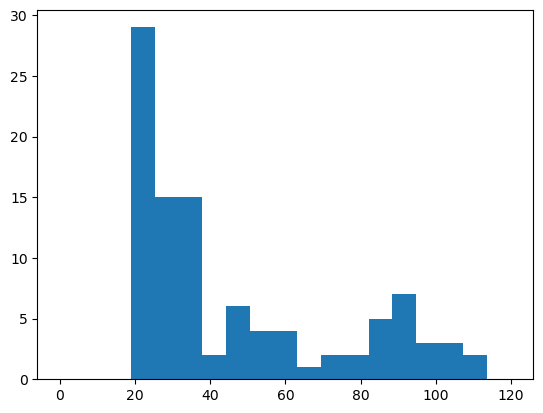

In [63]:
bins = np.linspace(0, 120, 20)

print(np.median(st_1['avg_dist']))
print(np.median(st_2['avg_dist']))

plt.hist(st_1['avg_dist'], bins=bins)
# plt.xlim((-1.5, 0.25))
plt.show()
plt.hist(st_2['avg_dist'], bins=bins)
# plt.xlim((-1.5, 0.25))
plt.show()

In [64]:
# xlim = (0, 120)
# for i in range(20):
#     dist = np.array(st_1.at[i, 'deldist'])
#     beta = np.array(st_1.at[i, 'beta'])

#     if len(dist) >10:

#         # M = fit_line_p_norm(dist, np.log10(beta), 1)
#         # slope1[i] = M[0]
#         plt.figure()
#         plt.scatter(dist, np.log10(beta), c='k', s=5)
#         plt.xlim(xlim)
#         # plt.yscale('log')

#         # plt.plot(X, M[0]*X + M[1], c='r')

#         plt.show()

In [65]:
# xlim = [1, 5]
# X = np.array([0, 5])
# slope1 = np.empty(len(st_1), dtype=float)
# slope2 = np.empty(len(st_1), dtype=float)

# B1_deldist = np.empty(len(st_1), dtype=float)
# B2_deldist = np.empty(len(st_1), dtype=float)

# B1_deldist[:] = np.nan
# B2_deldist[:] = np.nan

# # loop over common stations
# slope1[:] = np.nan
# slope2[:] = np.nan
# for i in range(64):
#     stid = st_1['stname'].values[i]
#     j = np.where(st_2['stname'].values==stid)[0]

#     # if station is common to both DFs, then:
#     if len(j)>0:
#         j = j[0]
#         qmag1 = np.array(st_1.at[i, 'qmag'])
#         beta1 = np.array(st_1.at[i, 'beta'])

#         qmag2 = np.array(st_2.at[j, 'qmag'])
#         beta2 = np.array(st_2.at[j, 'beta'])

#         if len(qmag1) >10:
#             # print(sum(qmag1<=3.0), sum(qmag2<=3.0), st_1['stname'].values[i], st_2['stname'].values[j])
#             assert st_1['stname'].values[i]==st_2['stname'].values[j], print('uh oh')

#             Xavg1, Yavg1 = get_bins_and_averages(qmag1, np.log10(beta1), edges=edges, method='median')
#             Xavg2, Yavg2 = get_bins_and_averages(qmag2, np.log10(beta2), edges=edges, method='median')

#             if len(Xavg1)>1 and len(Xavg2)>1:
#                 # M1 = fit_line_p_norm(Xavg1, Yavg1, 1)
#                 # M2 = fit_line_p_norm(Xavg2, Yavg2, 1)

#                 M1 = st_1[['beta_slope', 'beta_y']].values[i,:]
#                 M2 = st_2[['beta_slope', 'beta_y']].values[j,:]

#                 slope1[i] = M1[0]
#                 slope2[i] = M2[0]

#                 B1_deldist[i] = st_1['B1_sdist'].values[i] - st_2['B1_sdist'].values[j]
#                 B2_deldist[i] = st_1['B2_sdist'].values[i] - st_2['B2_sdist'].values[j]


#                 if i < 10:
#                     plt.figure()
#                     plt.title(st_1['stname'].values[i])
#                     plt.scatter(qmag1, np.log10(beta1), c='k', s=1, marker='.')
#                     plt.scatter(qmag2, np.log10(beta2), c='r', s=1, marker='.')

#                     plt.scatter(Xavg1, Yavg1, edgecolors='k', s=100, marker='s', facecolor='none')
#                     plt.scatter(Xavg2, Yavg2, edgecolors='r', s=100, marker='s', facecolor='none')
                    
#                     plt.xlim(xlim)
#                     # plt.yscale('log')

#                     plt.plot(X, M1[0]*X + M1[1], c='k', label='Box 1 fit')
#                     plt.plot(X, M2[0]*X + M2[1], c='r', label='Box 2 fit')

#                     plt.xlabel("Magnitude")
#                     plt.ylabel(r"$\log \beta$")
#                     plt.legend(loc='upper right')

#                     plt.show()



# keep_bool = ~np.logical_or(np.isnan(slope1), np.isnan(slope2))
# slope1 = slope1[keep_bool]
# slope2 = slope2[keep_bool]
# B1_deldist = B1_deldist[keep_bool]
# B2_deldist = B2_deldist[keep_bool]
# slopediff = slope1 - slope2

# print(f"Box B1 median slope: {np.nanmedian(slope1)}")
# print(f"Box B2 median slope: {np.nanmedian(slope2)}")
# print(f"Median difference: {np.nanmedian(slopediff)}")

# bins = np.linspace(-2, 2, 41)
# plt.figure()
# plt.hist(slopediff, bins=bins)
# plt.axvline(np.nanmedian(slopediff), c='k', label=f'Median = {np.nanmedian(slopediff):.3f}')
# plt.xlabel('Box 1 slope - Box 2 slope')
# plt.ylabel('N')
# plt.legend(loc='upper left')
# plt.xlim((-2, 2))
# plt.show()

# plt.figure()
# plt.scatter(B1_deldist, slopediff, c='k')
# plt.scatter(B2_deldist, slopediff, c='r')
# plt.show()


# # slope2 = np.zeros(len(st_2)) - 99.0
# # for i in range(len(st_2)):
# #     qmag = np.array(st_2.at[i, 'qmag'])
# #     beta = np.array(st_2.at[i, 'beta'])

# #     if len(qmag) >1:

# #         M = fit_line_p_norm(qmag, np.log10(beta), 1)
# #         slope2[i] = M[0]

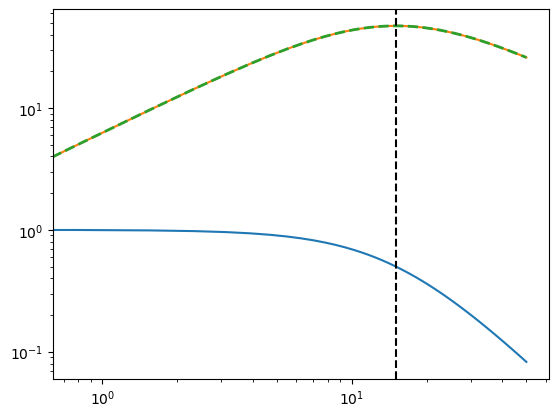

In [66]:
import seismo_functions as sf

f = np.linspace(0, 50, 65)
Sd = sf.get_brune_model(1, 15, f, output='disp')
Sv = sf.get_brune_model(1, 15, f, output='vel')

Sv2 = Sd * 2 * np.pi * f

plt.figure()
plt.plot(f, Sd)
plt.plot(f, Sv)
plt.plot(f, Sv2, linewidth=2, linestyle='--')

plt.axvline(15, color='k', linestyle='--')
plt.xscale('log')
plt.yscale('log')
plt.show()

